# Real Estate Investment Advisor

## Predicting Property Profitability & Future Value

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## 2. Load Dataset

In [5]:
df = pd.read_csv("../data/india_housing_prices.csv")

df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


## 3. Understand Dataset

In [6]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (250000, 23)

Column Names:
['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                            

## 4. Data Cleaning

In [7]:
# Check missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of Duplicate Rows:", df.duplicated().sum())

Missing Values in Each Column:
ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

Number of Duplicate Rows: 0


In [8]:
# Summary statistics for numerical columns
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [9]:
# Check whether Price_per_SqFt is consistent with Price_in_Lakhs and Size_in_SqFt

calculated_price_per_sqft = (
    df["Price_in_Lakhs"] * 100000 / df["Size_in_SqFt"]
)

comparison = pd.DataFrame({
    "Price_in_Lakhs": df["Price_in_Lakhs"],
    "Size_in_SqFt": df["Size_in_SqFt"],
    "Dataset_Price_per_SqFt": df["Price_per_SqFt"],
    "Calculated_Price_per_SqFt": calculated_price_per_sqft
})

comparison.head(10)

,Price_in_Lakhs,Size_in_SqFt,Dataset_Price_per_SqFt,Calculated_Price_per_SqFt
0,489.76,4740,0.10,10332.489451
1,195.52,2364,0.08,8270.727580
2,183.79,3642,0.05,5046.403075
3,300.29,2741,0.11,10955.490697
4,182.90,4823,0.04,3792.245490
5,135.28,3500,0.04,3865.142857
6,318.12,4826,0.07,6591.794447
7,141.39,4252,0.03,3325.258702
8,189.16,2678,0.07,7063.480209
9,187.42,1393,0.13,13454.414932


In [10]:
# Verify Price_per_SqFt across the entire dataset

calculated_price_per_sqft = (
    df["Price_in_Lakhs"] / df["Size_in_SqFt"]
)

difference = (
    df["Price_per_SqFt"] - calculated_price_per_sqft
).abs()

print("Maximum difference:", difference.max())
print("Mean difference:", difference.mean())
print("Rows with difference > 0.01:", (difference > 0.01).sum())

Maximum difference: 0.0050000000000000044
Mean difference: 0.0025106142498846334
Rows with difference > 0.01: 0


In [11]:
# Inspect the Amenities column

print("Number of unique Amenities values:", df["Amenities"].nunique())

print("\nSample Amenities values:")
print(df["Amenities"].unique()[:20])

Number of unique Amenities values: 325

Sample Amenities values:
['Playground, Gym, Garden, Pool, Clubhouse'
 'Playground, Clubhouse, Pool, Gym, Garden'
 'Clubhouse, Pool, Playground, Gym'
 'Playground, Clubhouse, Gym, Pool, Garden'
 'Playground, Garden, Gym, Pool, Clubhouse' 'Playground, Clubhouse'
 'Clubhouse, Garden, Playground' 'Gym, Pool, Clubhouse, Playground'
 'Garden, Clubhouse, Playground' 'Clubhouse, Playground, Garden, Gym'
 'Clubhouse' 'Clubhouse, Gym, Playground, Pool'
 'Clubhouse, Garden, Gym, Playground, Pool' 'Garden, Gym, Playground'
 'Playground' 'Pool, Playground, Garden, Gym' 'Pool, Clubhouse, Gym'
 'Garden, Clubhouse, Pool, Gym, Playground' 'Pool, Playground, Clubhouse'
 'Clubhouse, Gym, Garden, Pool, Playground']


In [12]:
# Create Amenity Density Score

df["Amenity_Density_Score"] = (
    df["Amenities"]
    .str.split(",")
    .str.len()
)

# Check the new feature
print("Amenity Density Score created successfully.")

print("\nSample values:")
print(df[["Amenities", "Amenity_Density_Score"]].head(10))

print("\nValue counts:")
print(df["Amenity_Density_Score"].value_counts().sort_index())

Amenity Density Score created successfully.

Sample values:
                                  Amenities  Amenity_Density_Score
0  Playground, Gym, Garden, Pool, Clubhouse                      5
1  Playground, Clubhouse, Pool, Gym, Garden                      5
2          Clubhouse, Pool, Playground, Gym                      4
3  Playground, Clubhouse, Gym, Pool, Garden                      5
4  Playground, Garden, Gym, Pool, Clubhouse                      5
5                     Playground, Clubhouse                      2
6             Clubhouse, Garden, Playground                      3
7          Gym, Pool, Clubhouse, Playground                      4
8             Garden, Clubhouse, Playground                      3
9        Clubhouse, Playground, Garden, Gym                      4

Value counts:
Amenity_Density_Score
1    50106
2    49806
3    49862
4    50362
5    49864
Name: count, dtype: int64


In [13]:
# Calculate median values for investment classification

median_price = df["Price_in_Lakhs"].median()
median_price_per_sqft = df["Price_per_SqFt"].median()
median_amenities = df["Amenity_Density_Score"].median()

print("Median Price (Lakhs):", median_price)
print("Median Price per SqFt (Lakhs):", median_price_per_sqft)
print("Median Amenity Density Score:", median_amenities)

Median Price (Lakhs): 253.87
Median Price per SqFt (Lakhs): 0.09
Median Amenity Density Score: 3.0


In [14]:
# Create Good_Investment target using a multi-factor rule

median_price = df["Price_in_Lakhs"].median()
median_price_per_sqft = df["Price_per_SqFt"].median()
median_amenities = df["Amenity_Density_Score"].median()

# Create individual investment conditions
price_condition = df["Price_in_Lakhs"] <= median_price
price_per_sqft_condition = df["Price_per_SqFt"] <= median_price_per_sqft
amenity_condition = df["Amenity_Density_Score"] >= median_amenities

# Count how many conditions each property satisfies
investment_score = (
    price_condition.astype(int)
    + price_per_sqft_condition.astype(int)
    + amenity_condition.astype(int)
)

# Good Investment = 1 if at least 2 conditions are satisfied
df["Good_Investment"] = (investment_score >= 2).astype(int)

# Check the result
print("Good_Investment distribution:")
print(df["Good_Investment"].value_counts())

print("\nGood_Investment percentage:")
print(df["Good_Investment"].value_counts(normalize=True) * 100)

Good_Investment distribution:
Good_Investment
1    132267
0    117733
Name: count, dtype: int64

Good_Investment percentage:
Good_Investment
1    52.9068
0    47.0932
Name: proportion, dtype: float64


In [15]:
# Create Future_Price_5Y target
# Assuming 8% annual property price appreciation for 5 years

annual_growth_rate = 0.08
years = 5

df["Future_Price_5Y"] = (
    df["Price_in_Lakhs"] * (1 + annual_growth_rate) ** years
)

# Check the new target
print("Future_Price_5Y created successfully.")

print("\nSample values:")
print(
    df[
        ["Price_in_Lakhs", "Future_Price_5Y"]
    ].head(10)
)

print("\nFuture_Price_5Y Summary:")
print(df["Future_Price_5Y"].describe())

Future_Price_5Y created successfully.

Sample values:
   Price_in_Lakhs  Future_Price_5Y
0          489.76       719.618119
1          195.52       287.283026
2          183.79       270.047807
3          300.29       441.224528
4          182.90       268.740105
5          135.28       198.770702
6          318.12       467.422648
7          141.39       207.748297
8          189.16       277.938099
9          187.42       275.381468

Future_Price_5Y Summary:
count    250000.000000
mean        374.071613
std         207.689408
min          14.693281
25%         194.759437
50%         373.018319
75%         553.760366
max         734.664038
Name: Future_Price_5Y, dtype: float64


In [16]:
print("Target Variables Summary")
print("=" * 40)

print("\nGood_Investment:")
print(df["Good_Investment"].value_counts())

print("\nFuture_Price_5Y:")
print(df["Future_Price_5Y"].describe())

Target Variables Summary

Good_Investment:
Good_Investment
1    132267
0    117733
Name: count, dtype: int64

Future_Price_5Y:
count    250000.000000
mean        374.071613
std         207.689408
min          14.693281
25%         194.759437
50%         373.018319
75%         553.760366
max         734.664038
Name: Future_Price_5Y, dtype: float64


## 5. Feature Engineering

### 5.1 Amenity Density Score

In [17]:
df["Amenity_Density_Score"] = (
    df["Amenities"]
    .str.split(",")
    .str.len()
)

print("Amenity Density Score created successfully.")

print("\nSample values:")
print(
    df[
        ["Amenities", "Amenity_Density_Score"]
    ].head(10)
)

print("\nValue counts:")
print(
    df["Amenity_Density_Score"]
    .value_counts()
    .sort_index()
)

Amenity Density Score created successfully.

Sample values:
                                  Amenities  Amenity_Density_Score
0  Playground, Gym, Garden, Pool, Clubhouse                      5
1  Playground, Clubhouse, Pool, Gym, Garden                      5
2          Clubhouse, Pool, Playground, Gym                      4
3  Playground, Clubhouse, Gym, Pool, Garden                      5
4  Playground, Garden, Gym, Pool, Clubhouse                      5
5                     Playground, Clubhouse                      2
6             Clubhouse, Garden, Playground                      3
7          Gym, Pool, Clubhouse, Playground                      4
8             Garden, Clubhouse, Playground                      3
9        Clubhouse, Playground, Garden, Gym                      4

Value counts:
Amenity_Density_Score
1    50106
2    49806
3    49862
4    50362
5    49864
Name: count, dtype: int64


### 5.2 Create Good Investment Target

A property is considered a good investment using a multi-factor score.

The following conditions are considered:

- Price is less than or equal to the median property price.
- Price per SqFt is less than or equal to the median Price per SqFt.
- Amenity Density Score is greater than or equal to the median.

If at least 2 of these 3 conditions are satisfied, the property is classified as a Good Investment (1). Otherwise, it is classified as 0.

In [18]:
# Calculate median values

median_price = df["Price_in_Lakhs"].median()
median_price_per_sqft = df["Price_per_SqFt"].median()
median_amenities = df["Amenity_Density_Score"].median()

# Create individual conditions

price_condition = df["Price_in_Lakhs"] <= median_price

price_per_sqft_condition = (
    df["Price_per_SqFt"] <= median_price_per_sqft
)

amenity_condition = (
    df["Amenity_Density_Score"] >= median_amenities
)

# Calculate investment score

investment_score = (
    price_condition.astype(int)
    + price_per_sqft_condition.astype(int)
    + amenity_condition.astype(int)
)

# Create Good_Investment target

df["Good_Investment"] = (
    investment_score >= 2
).astype(int)

print("Good_Investment target created successfully.")

print("\nTarget Distribution:")
print(df["Good_Investment"].value_counts())

print("\nTarget Percentage:")
print(
    df["Good_Investment"]
    .value_counts(normalize=True) * 100
)

Good_Investment target created successfully.

Target Distribution:
Good_Investment
1    132267
0    117733
Name: count, dtype: int64

Target Percentage:
Good_Investment
1    52.9068
0    47.0932
Name: proportion, dtype: float64


### 5.3 Create Future Price Target

The future property price after 5 years is estimated using a fixed annual growth rate.

Formula:

Future Price = Current Price × (1 + r)^t

Where:

- Current Price = Price_in_Lakhs
- r = Annual growth rate (8%)
- t = Number of years (5)

Therefore:

Future_Price_5Y = Price_in_Lakhs × (1 + 0.08)^5

In [19]:
# Set annual growth rate and prediction period

annual_growth_rate = 0.08
years = 5

# Calculate future property price after 5 years

df["Future_Price_5Y"] = (
    df["Price_in_Lakhs"] *
    (1 + annual_growth_rate) ** years
)

print("Future_Price_5Y target created successfully.")

print("\nSample values:")
print(
    df[
        ["Price_in_Lakhs", "Future_Price_5Y"]
    ].head(10)
)

print("\nFuture_Price_5Y Summary:")
print(df["Future_Price_5Y"].describe())

Future_Price_5Y target created successfully.

Sample values:
   Price_in_Lakhs  Future_Price_5Y
0          489.76       719.618119
1          195.52       287.283026
2          183.79       270.047807
3          300.29       441.224528
4          182.90       268.740105
5          135.28       198.770702
6          318.12       467.422648
7          141.39       207.748297
8          189.16       277.938099
9          187.42       275.381468

Future_Price_5Y Summary:
count    250000.000000
mean        374.071613
std         207.689408
min          14.693281
25%         194.759437
50%         373.018319
75%         553.760366
max         734.664038
Name: Future_Price_5Y, dtype: float64


### 5.4 Target Variables Summary

The project uses two target variables:

- `Good_Investment` – Classification target
- `Future_Price_5Y` – Regression target

In [20]:
print("Target Variables Summary")
print("=" * 40)

print("\nGood_Investment:")
print(df["Good_Investment"].value_counts())

print("\nGood_Investment Percentage:")
print(
    df["Good_Investment"]
    .value_counts(normalize=True) * 100
)

print("\nFuture_Price_5Y:")
print(df["Future_Price_5Y"].describe())

Target Variables Summary

Good_Investment:
Good_Investment
1    132267
0    117733
Name: count, dtype: int64

Good_Investment Percentage:
Good_Investment
1    52.9068
0    47.0932
Name: proportion, dtype: float64

Future_Price_5Y:
count    250000.000000
mean        374.071613
std         207.689408
min          14.693281
25%         194.759437
50%         373.018319
75%         553.760366
max         734.664038
Name: Future_Price_5Y, dtype: float64


## 6. Exploratory Data Analysis

EDA is performed to understand the distribution, relationships, trends, and patterns present in the real estate dataset.

### 6.1 Distribution of Property Prices

Question 1: What is the distribution of property prices?

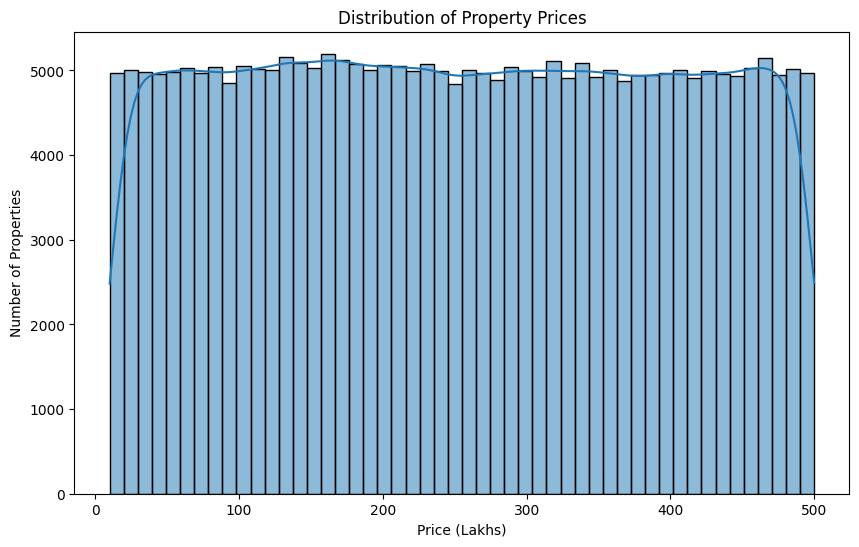

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Price_in_Lakhs"],
    bins=50,
    kde=True
)

plt.title("Distribution of Property Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Properties")

plt.show()

"This graph shows how property prices are distributed in the dataset. I used a histogram with a KDE curve to understand the frequency and overall shape of the price distribution. It helps identify whether most properties are concentrated around a particular price range."

#### Question 2: What is the distribution of property sizes?

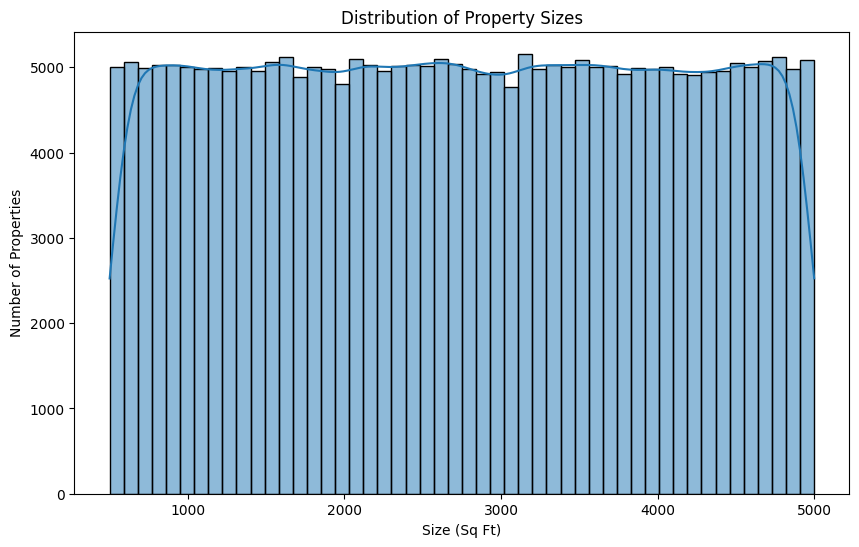

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Size_in_SqFt"],
    bins=50,
    kde=True
)

plt.title("Distribution of Property Sizes")
plt.xlabel("Size (Sq Ft)")
plt.ylabel("Number of Properties")

plt.show()

"This graph shows the distribution of property sizes in square feet. I used a histogram to see how frequently different property sizes occur. This helps us understand whether the dataset mainly contains small, medium, or large properties."

#### Question 3: How does the price per sq ft vary by property type?

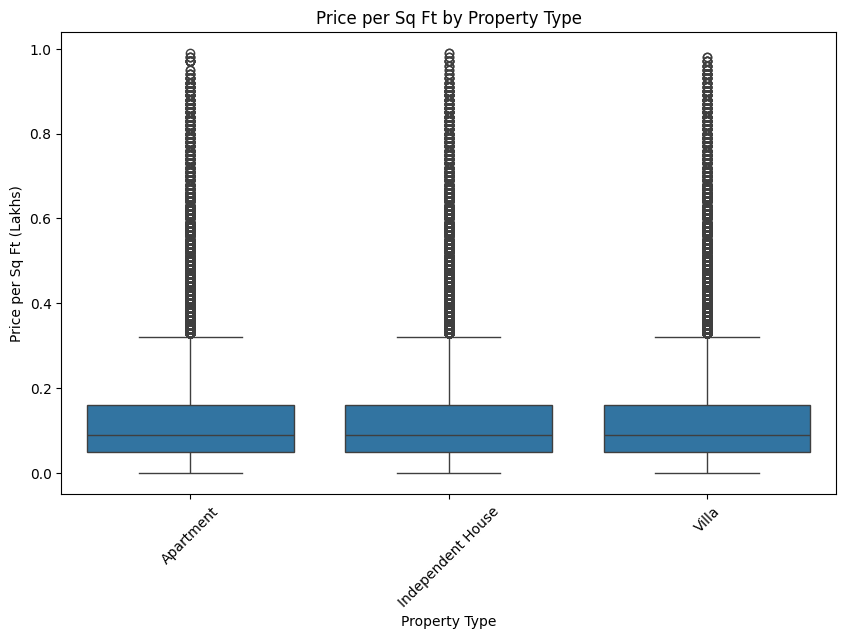

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Property_Type",
    y="Price_per_SqFt"
)

plt.title("Price per Sq Ft by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Price per Sq Ft (Lakhs)")

plt.xticks(rotation=45)

plt.show()

"Here I compare the price per square foot across different property types. I used a boxplot because it shows the median, spread, and possible outliers for each property type. This helps us understand how pricing differs between property categories."

#### Question 4: Is there a relationship between property size and price?

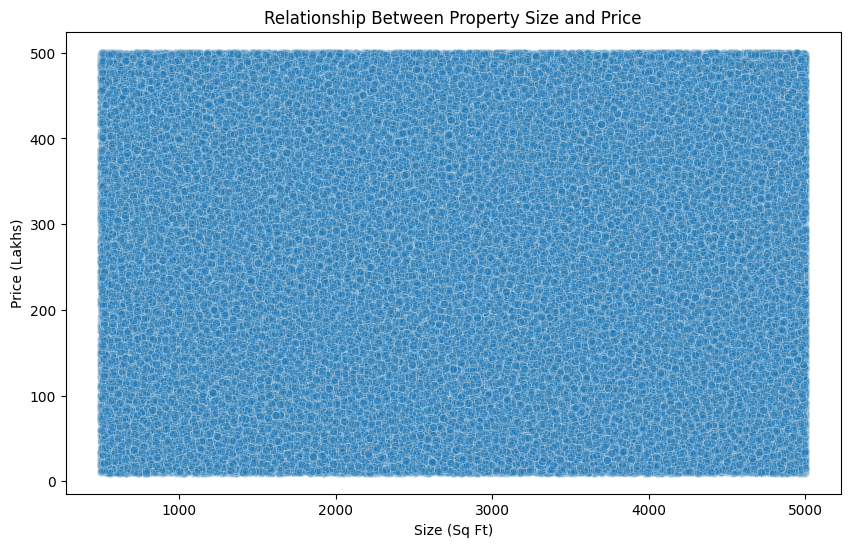

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Size_in_SqFt",
    y="Price_in_Lakhs",
    alpha=0.3
)

plt.title("Relationship Between Property Size and Price")
plt.xlabel("Size (Sq Ft)")
plt.ylabel("Price (Lakhs)")

plt.show()

"This scatter plot is used to understand the relationship between property size and price. The size is on the X-axis and price is on the Y-axis. If the points generally move upward as size increases, it indicates a positive relationship between property size and price."

#### Question 5: Are there any outliers in price per sq ft or property size?


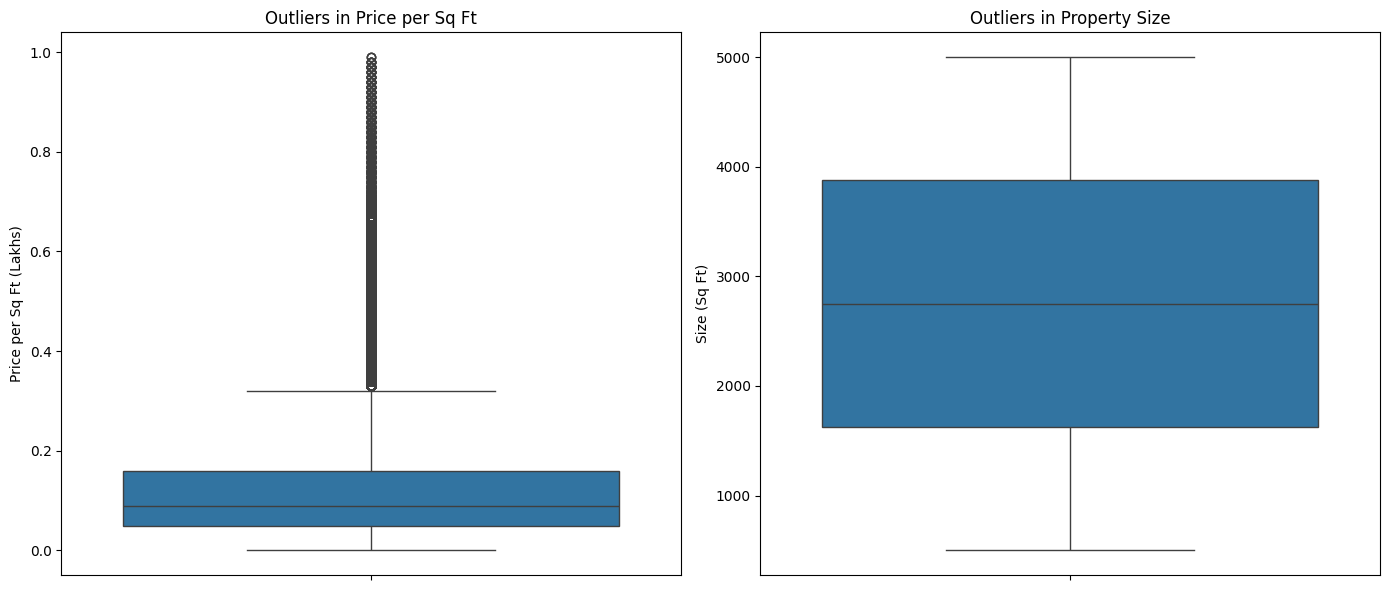

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    y=df["Price_per_SqFt"],
    ax=axes[0]
)

axes[0].set_title("Outliers in Price per Sq Ft")
axes[0].set_ylabel("Price per Sq Ft (Lakhs)")

sns.boxplot(
    y=df["Size_in_SqFt"],
    ax=axes[1]
)

axes[1].set_title("Outliers in Property Size")
axes[1].set_ylabel("Size (Sq Ft)")

plt.tight_layout()
plt.show()

"I used boxplots to identify possible outliers in price per square foot and property size. Points beyond the normal range of the boxplot can indicate unusually high or low values. Identifying outliers is important because extreme values can affect statistical analysis and machine learning models."

### 6.2 Location-Based Analysis

This section analyzes property prices, property age, and BHK patterns across different states, cities, and localities.

#### Question 6: What is the average price per sq ft by state?

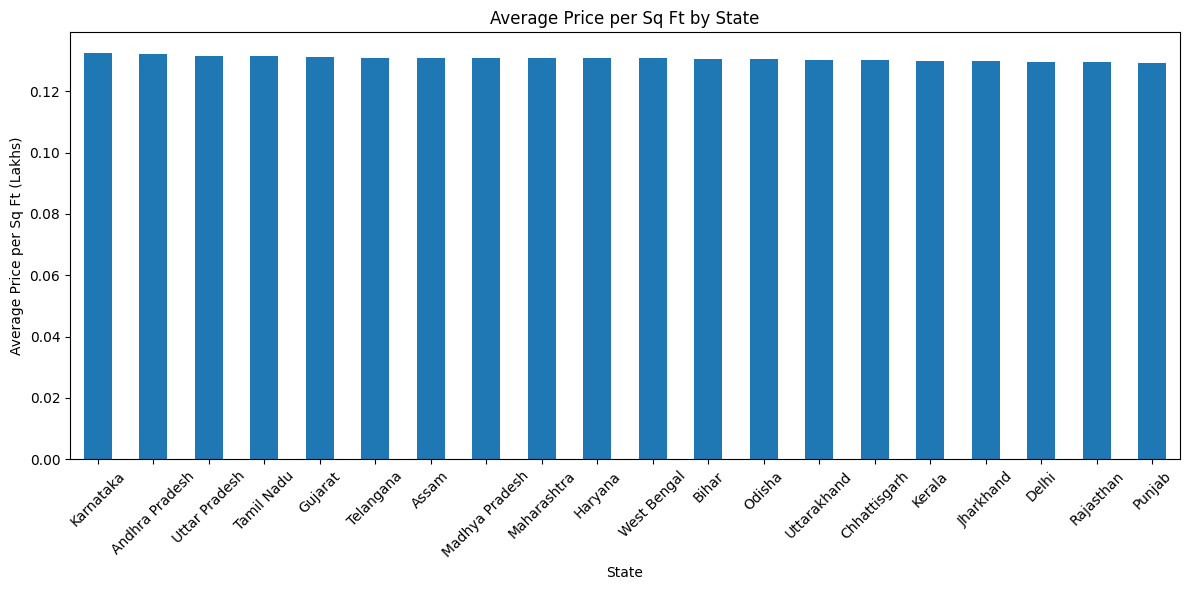

In [27]:
state_avg_price_sqft = (
    df.groupby("State")["Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

state_avg_price_sqft.plot(kind="bar")

plt.title("Average Price per Sq Ft by State")
plt.xlabel("State")
plt.ylabel("Average Price per Sq Ft (Lakhs)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

"I grouped the properties by state and calculated the average price per square foot for each state. The bar chart helps us compare property pricing levels across different states."

#### Question 7: What is the average property price by city?

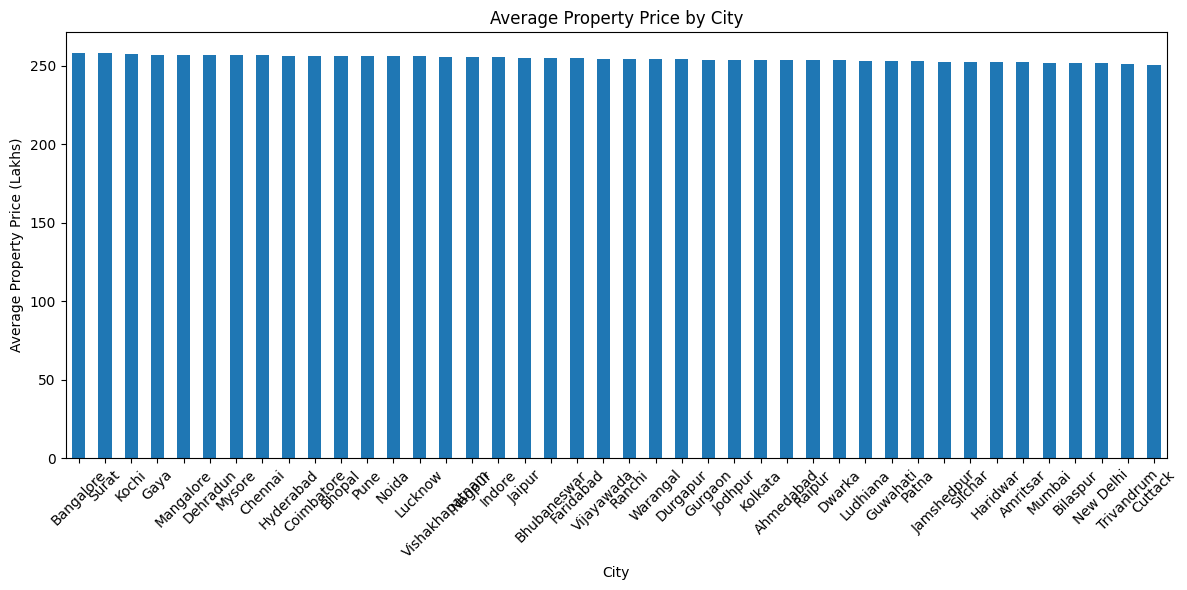

In [28]:
city_avg_price = (
    df.groupby("City")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

city_avg_price.plot(kind="bar")

plt.title("Average Property Price by City")
plt.xlabel("City")
plt.ylabel("Average Property Price (Lakhs)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

"Here I grouped the data by city and calculated the average property price. This helps us compare the overall property price levels between different cities."

#### Question 8: What is the median age of properties by locality?

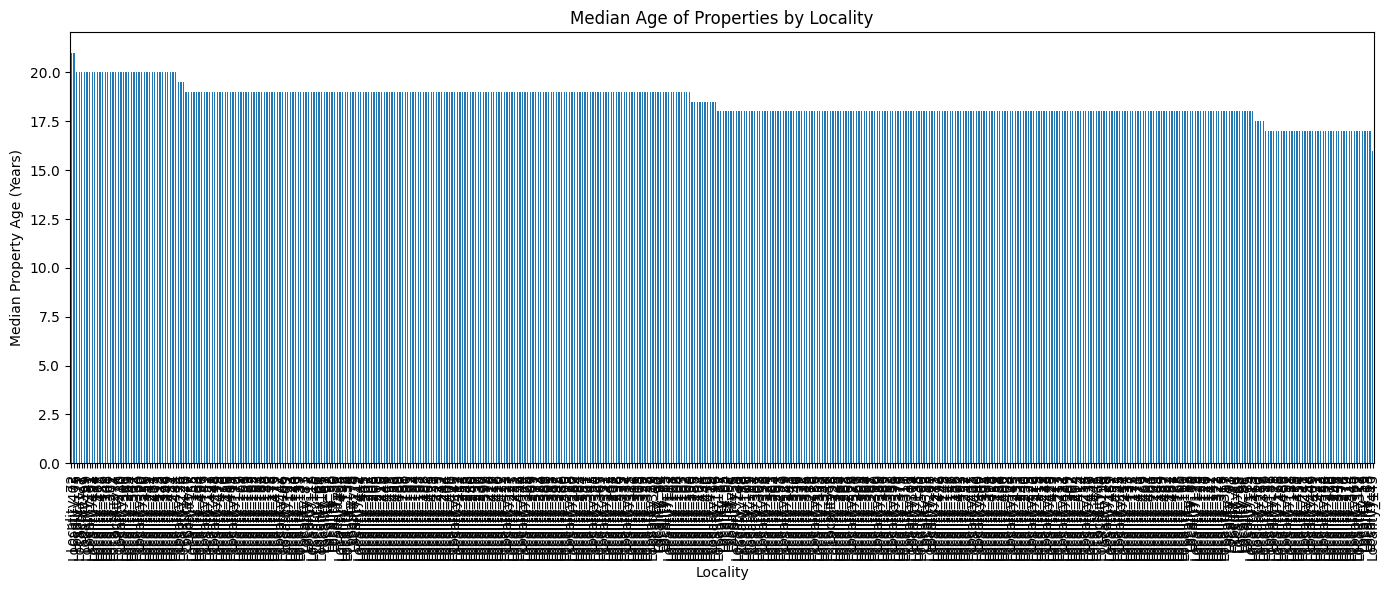

In [29]:
locality_median_age = (
    df.groupby("Locality")["Age_of_Property"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))

locality_median_age.plot(kind="bar")

plt.title("Median Age of Properties by Locality")
plt.xlabel("Locality")
plt.ylabel("Median Property Age (Years)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

"I grouped the properties by locality and calculated the median property age. I used the median because it represents the typical property age while being less affected by extreme values."

#### Question 9: How is BHK distributed across cities?

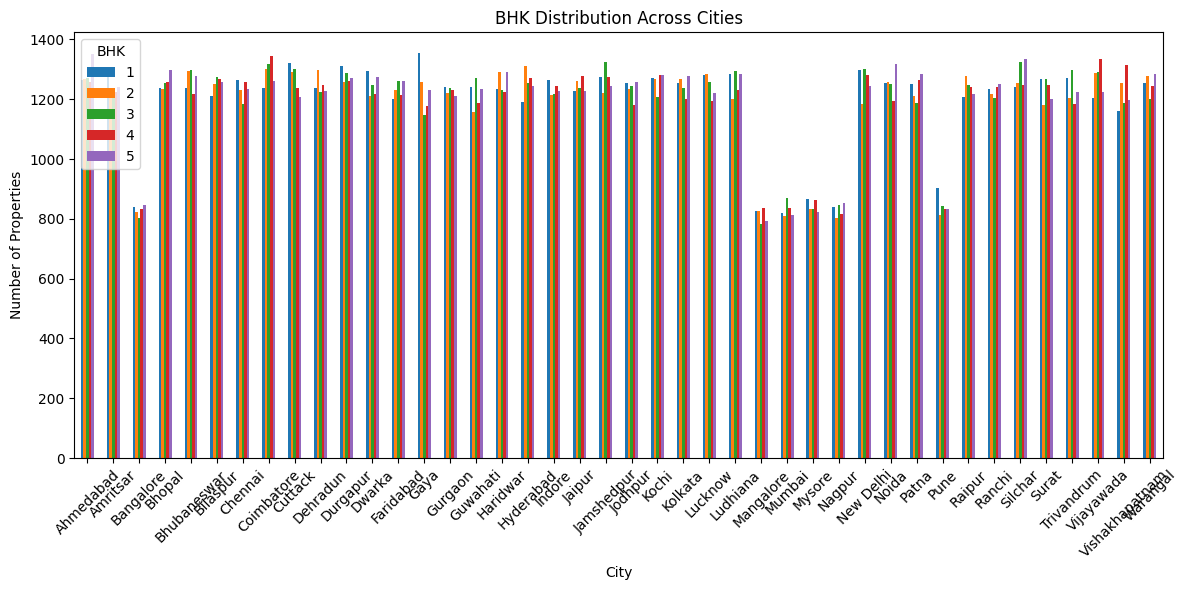

In [30]:
bhk_city = pd.crosstab(
    df["City"],
    df["BHK"]
)

bhk_city.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("BHK Distribution Across Cities")
plt.xlabel("City")
plt.ylabel("Number of Properties")

plt.xticks(rotation=45)

plt.legend(title="BHK")

plt.tight_layout()
plt.show()

"I used a cross-tabulation between city and BHK to count how many properties of each BHK type are present in each city. The grouped bar chart makes it easy to compare the BHK distribution across cities."

#### Question 10: What are the price trends for the top 5 most expensive localities?

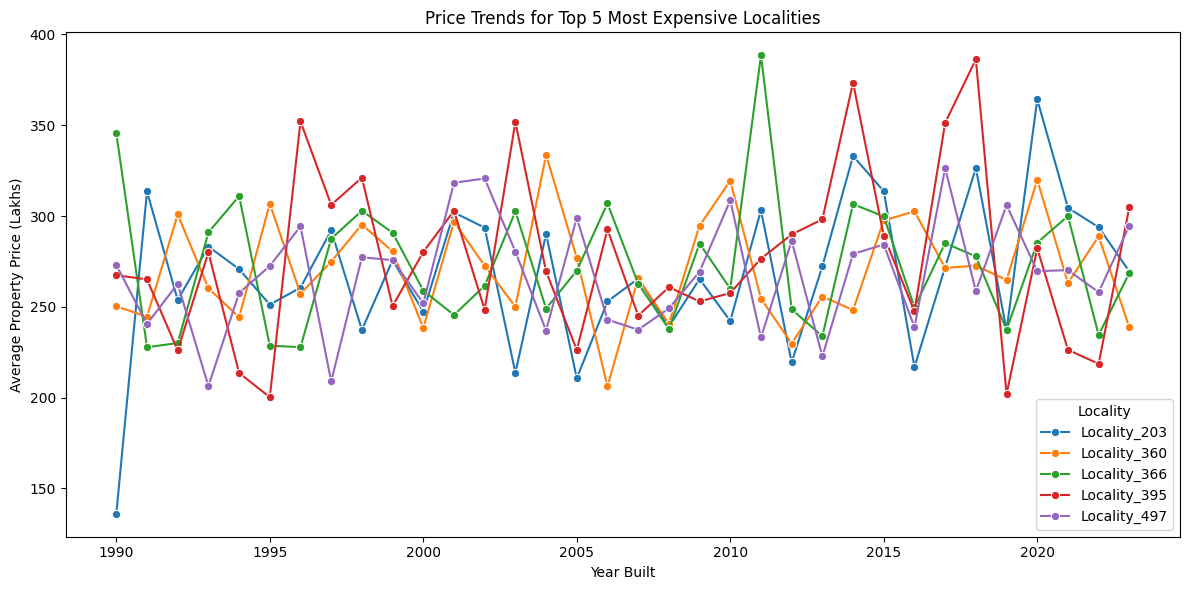

In [31]:
top_5_localities = (
    df.groupby("Locality")["Price_in_Lakhs"]
    .mean()
    .nlargest(5)
    .index
)

top_locality_data = df[
    df["Locality"].isin(top_5_localities)
]

locality_price_trend = (
    top_locality_data
    .groupby(["Year_Built", "Locality"])["Price_in_Lakhs"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=locality_price_trend,
    x="Year_Built",
    y="Price_in_Lakhs",
    hue="Locality",
    marker="o"
)

plt.title("Price Trends for Top 5 Most Expensive Localities")
plt.xlabel("Year Built")
plt.ylabel("Average Property Price (Lakhs)")

plt.legend(title="Locality")

plt.tight_layout()
plt.show()

"First, I identified the five localities with the highest average property prices. Then I grouped their properties by year built and calculated the average price. The line chart helps visualize how prices vary across these localities and construction years."

### 6.3 Feature Relationship & Correlation

This section analyzes relationships between numerical and categorical features and their relationship with property prices.

#### Question 11: How are numeric features correlated with each other?

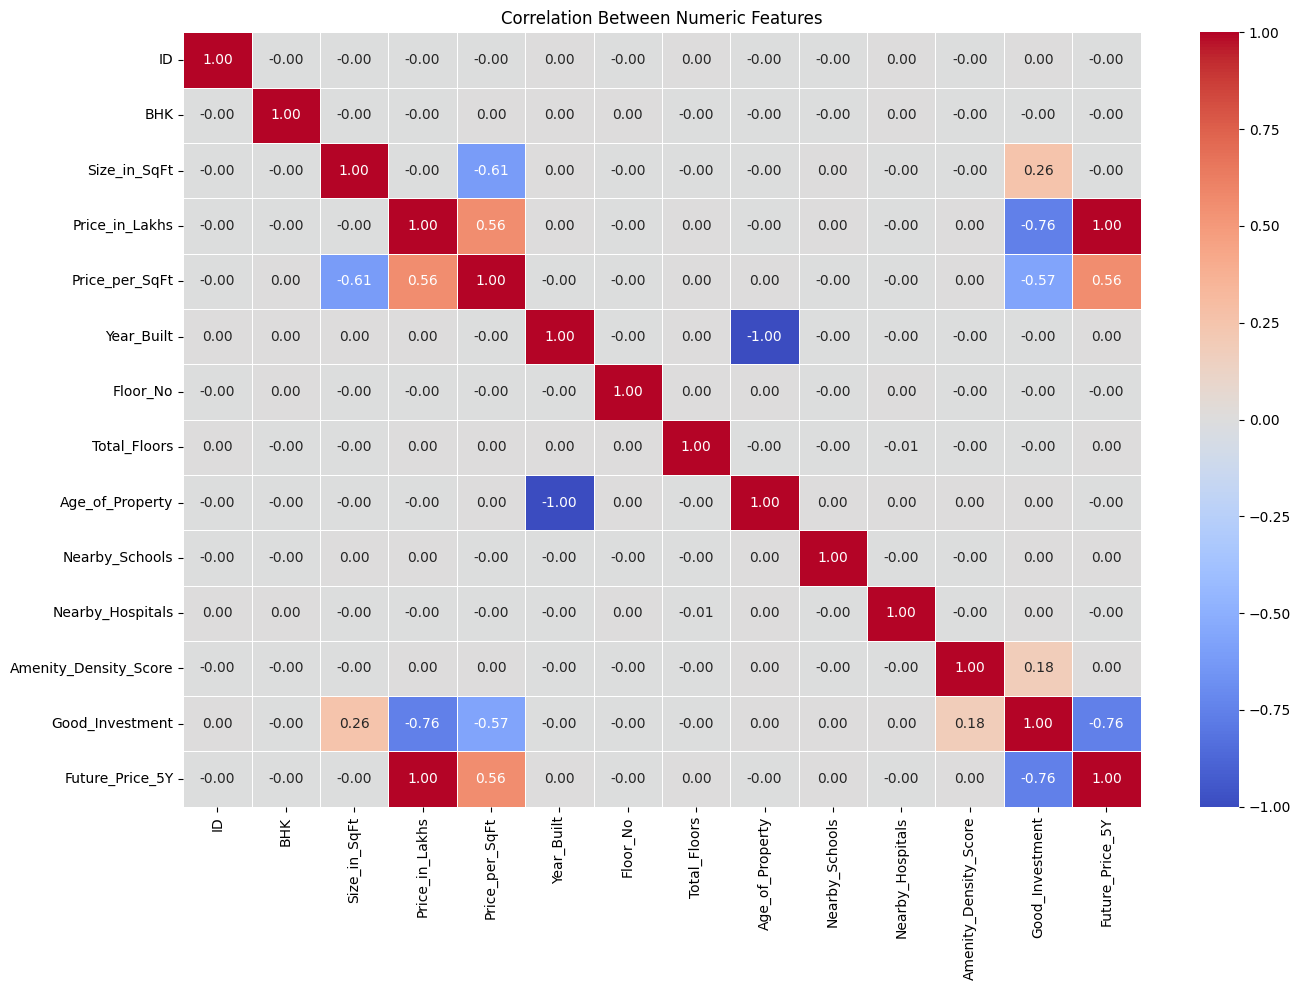

In [32]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Numeric Features")

plt.tight_layout()
plt.show()

"I used a correlation heatmap to understand the relationships between numerical features. The correlation value ranges from -1 to +1. A value close to +1 indicates a strong positive relationship, while a value close to -1 indicates a negative relationship."

#### Question 12: How do nearby schools relate to price per sq ft?

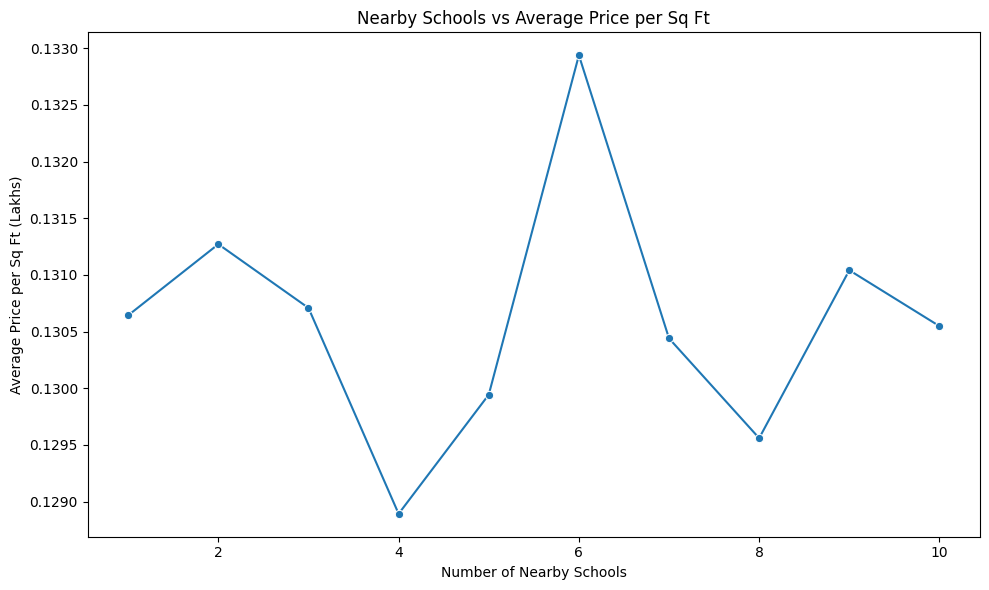

In [33]:
schools_price = (
    df.groupby("Nearby_Schools")["Price_per_SqFt"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=schools_price,
    x="Nearby_Schools",
    y="Price_per_SqFt",
    marker="o"
)

plt.title("Nearby Schools vs Average Price per Sq Ft")
plt.xlabel("Number of Nearby Schools")
plt.ylabel("Average Price per Sq Ft (Lakhs)")

plt.tight_layout()
plt.show()

"I grouped the properties according to the number of nearby schools and calculated the average price per square foot. This helps us understand whether properties with better access to schools have different price levels."

#### Question 13: How do nearby hospitals relate to price per sq ft?

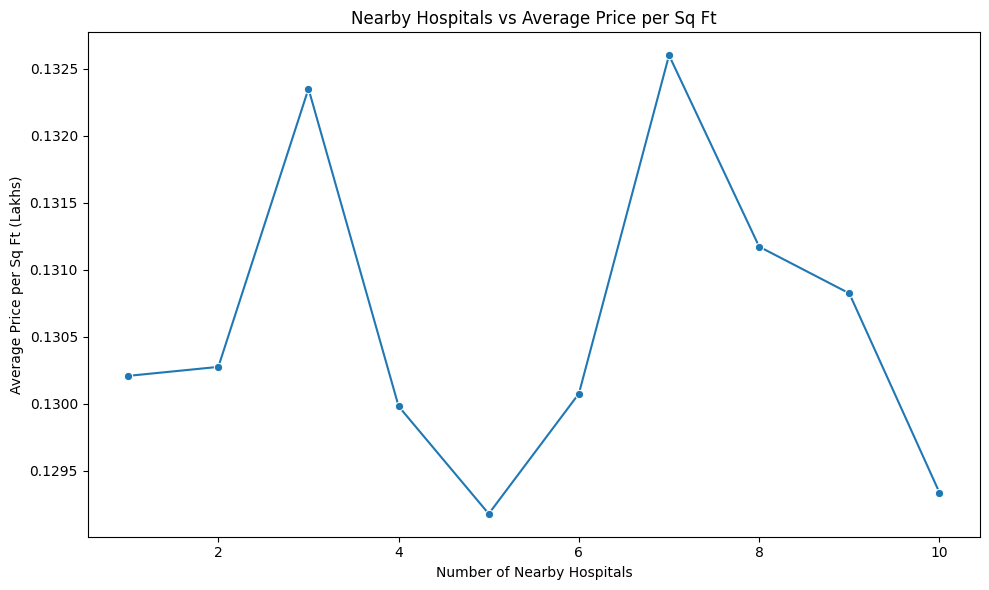

In [34]:
hospitals_price = (
    df.groupby("Nearby_Hospitals")["Price_per_SqFt"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=hospitals_price,
    x="Nearby_Hospitals",
    y="Price_per_SqFt",
    marker="o"
)

plt.title("Nearby Hospitals vs Average Price per Sq Ft")
plt.xlabel("Number of Nearby Hospitals")
plt.ylabel("Average Price per Sq Ft (Lakhs)")

plt.tight_layout()
plt.show()

"I grouped the properties based on the number of nearby hospitals and calculated the average price per square foot. This analysis helps us examine whether access to healthcare facilities is associated with property pricing."

#### Question 14: How does price vary by furnished status?

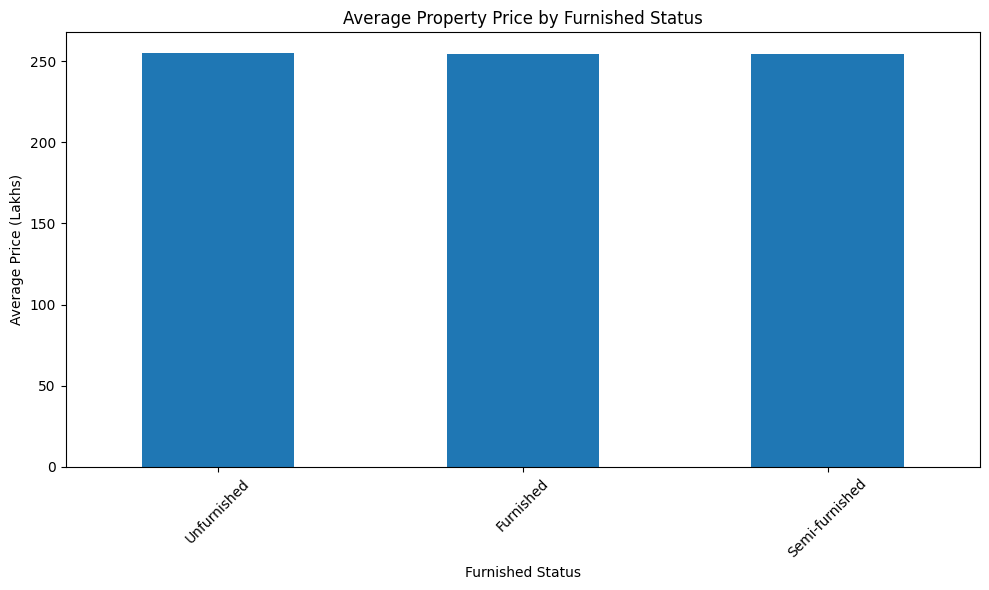

In [35]:
furnished_price = (
    df.groupby("Furnished_Status")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

furnished_price.plot(kind="bar")

plt.title("Average Property Price by Furnished Status")
plt.xlabel("Furnished Status")
plt.ylabel("Average Price (Lakhs)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

"I grouped properties according to their furnishing status and calculated the average property price. This allows us to compare the price levels of different furnishing categories."

#### Question 15: How does price per sq ft vary by property facing direction?

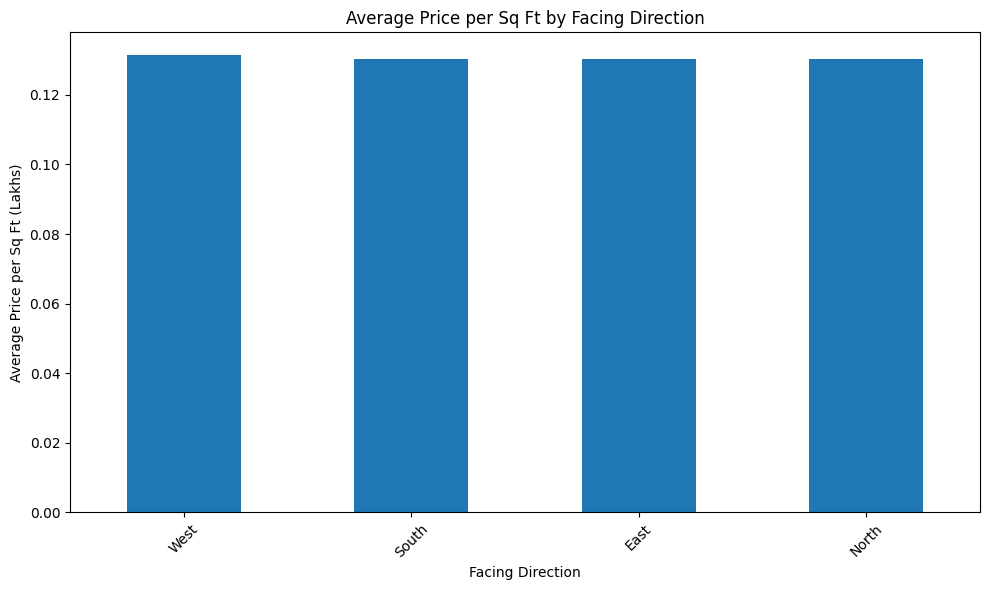

In [36]:
facing_price = (
    df.groupby("Facing")["Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

facing_price.plot(kind="bar")

plt.title("Average Price per Sq Ft by Facing Direction")
plt.xlabel("Facing Direction")
plt.ylabel("Average Price per Sq Ft (Lakhs)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

"I grouped properties by their facing direction and calculated the average price per square foot. This helps us compare whether property prices differ across different facing directions."

### 6.4 Investment / Amenities / Ownership Analysis

This section analyzes ownership, availability, parking, amenities, and public transport in relation to property pricing and investment potential.

#### Question 16: How many properties belong to each owner type?

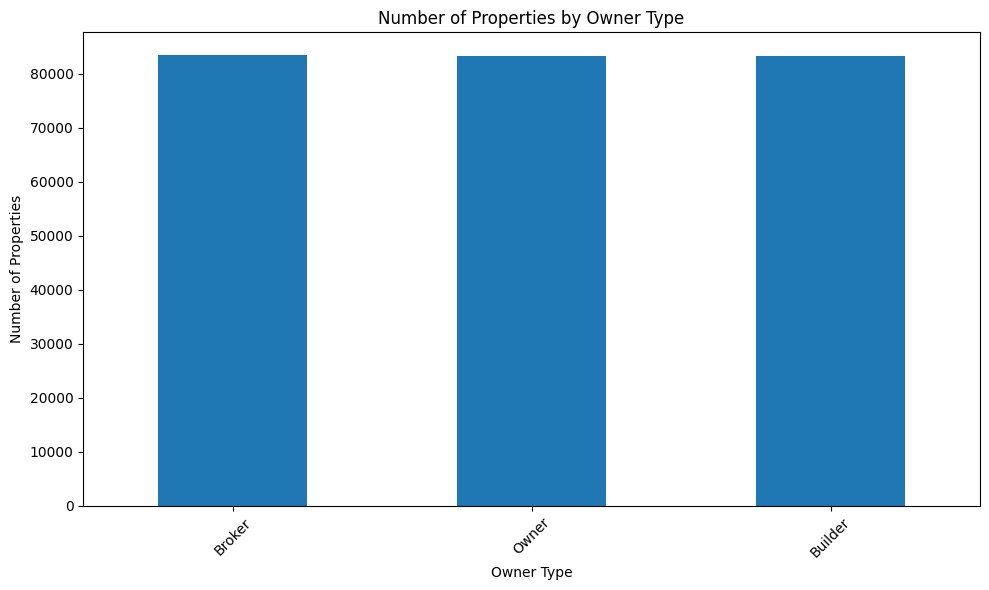

In [37]:
owner_counts = df["Owner_Type"].value_counts()

plt.figure(figsize=(10, 6))

owner_counts.plot(kind="bar")

plt.title("Number of Properties by Owner Type")
plt.xlabel("Owner Type")
plt.ylabel("Number of Properties")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

"I used value counts to calculate the number of properties belonging to each owner type. This helps us understand the composition of property ownership in the dataset."

#### Question 17: How many properties are available under each availability status?

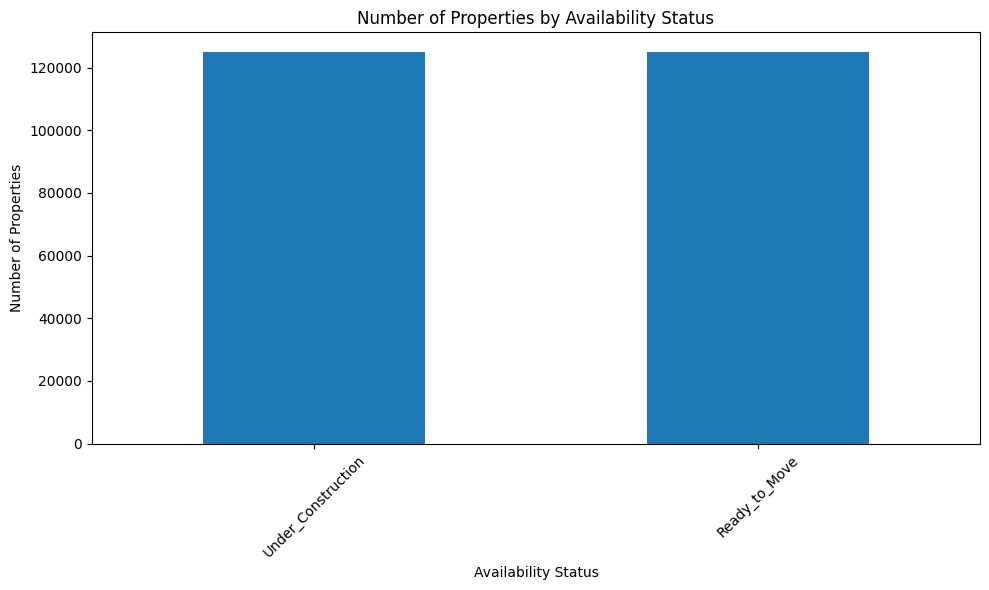

In [38]:
availability_counts = df["Availability_Status"].value_counts()

plt.figure(figsize=(10, 6))

availability_counts.plot(kind="bar")

plt.title("Number of Properties by Availability Status")
plt.xlabel("Availability Status")
plt.ylabel("Number of Properties")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

"I counted the number of properties under each availability status. This gives us an overview of how many properties are available under each category in the dataset."

#### Question 18: Does parking space affect property price?

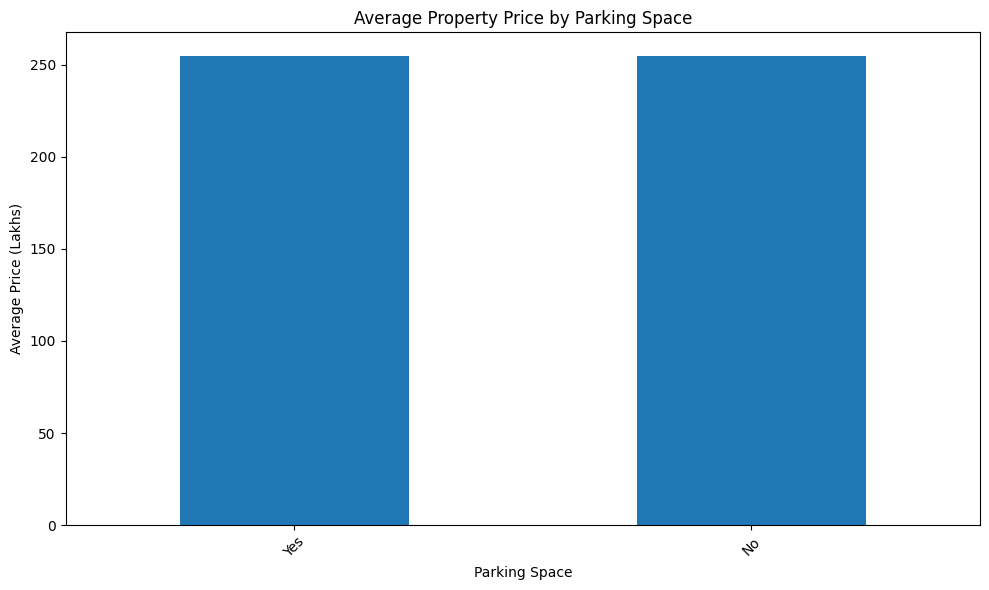

In [39]:
parking_price = (
    df.groupby("Parking_Space")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

parking_price.plot(kind="bar")

plt.title("Average Property Price by Parking Space")
plt.xlabel("Parking Space")
plt.ylabel("Average Price (Lakhs)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

"I grouped properties based on parking availability and calculated their average prices. This helps us compare the average property price between different parking categories."

#### Question 19: How do amenities affect price per sq ft?

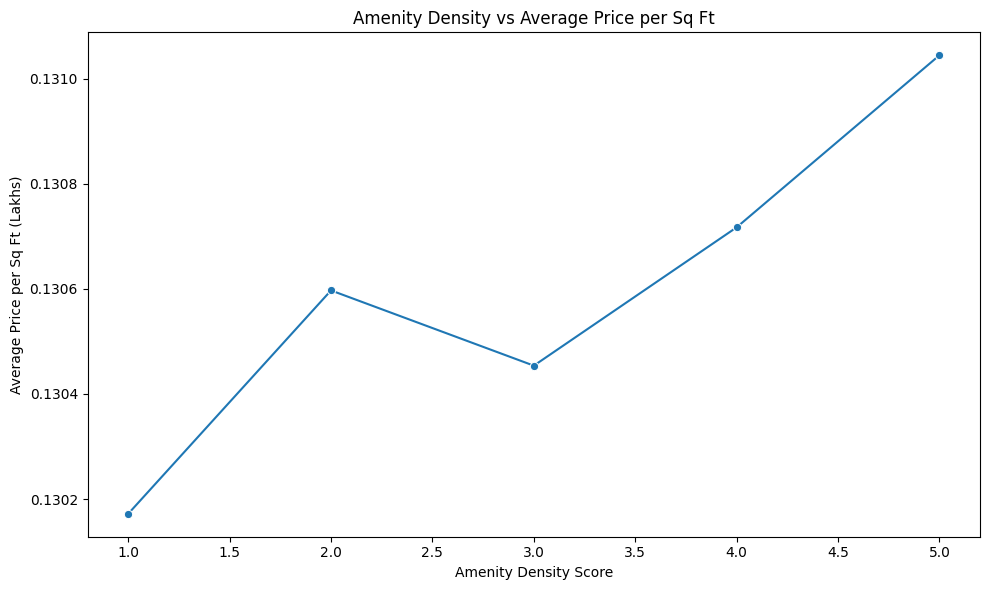

In [40]:
amenity_price = (
    df.groupby("Amenity_Density_Score")["Price_per_SqFt"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=amenity_price,
    x="Amenity_Density_Score",
    y="Price_per_SqFt",
    marker="o"
)

plt.title("Amenity Density vs Average Price per Sq Ft")
plt.xlabel("Amenity Density Score")
plt.ylabel("Average Price per Sq Ft (Lakhs)")

plt.tight_layout()
plt.show()

"I used the Amenity Density Score that I created during feature engineering. It represents the number of amenities available in a property. I compared this score with average price per square foot to understand whether properties with more amenities have different price levels."

#### Question 20: How does public transport accessibility relate to price per sq ft or investment potential?

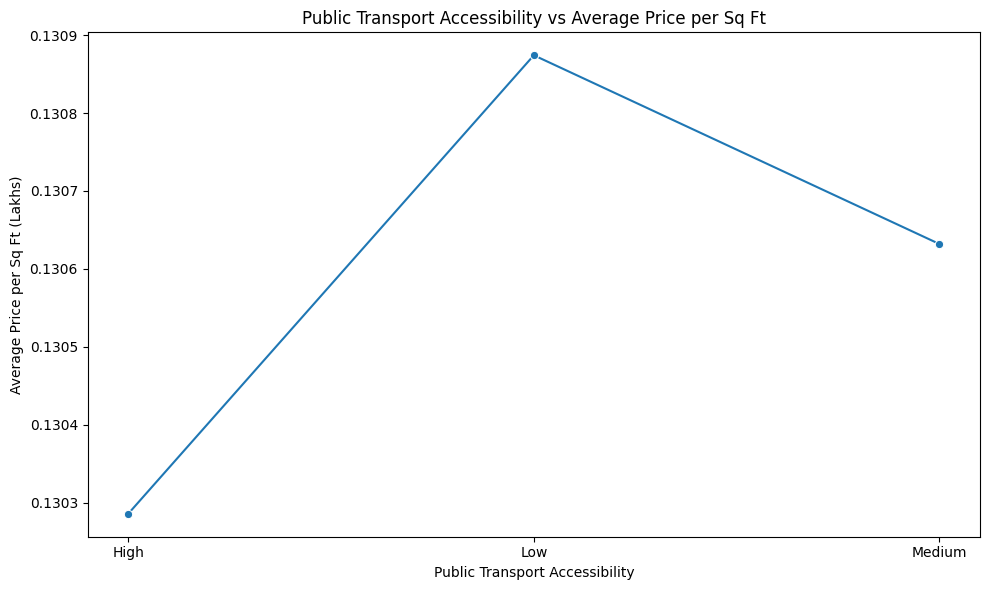

In [41]:
transport_price = (
    df.groupby("Public_Transport_Accessibility")
    .agg(
        Average_Price_per_SqFt=("Price_per_SqFt", "mean"),
        Investment_Rate=("Good_Investment", "mean")
    )
    .reset_index()
)

transport_price["Investment_Rate"] = (
    transport_price["Investment_Rate"] * 100
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=transport_price,
    x="Public_Transport_Accessibility",
    y="Average_Price_per_SqFt",
    marker="o"
)

plt.title("Public Transport Accessibility vs Average Price per Sq Ft")
plt.xlabel("Public Transport Accessibility")
plt.ylabel("Average Price per Sq Ft (Lakhs)")

plt.tight_layout()
plt.show()

"I grouped the properties based on public transport accessibility and calculated the average price per square foot. I also calculated the percentage of properties classified as Good Investment for each accessibility level. This helps us examine the relationship between transport accessibility, property pricing, and the investment target."

## 7. Data Preprocessing for Machine Learning

### 7.1 Define Features and Target Variables

For classification, the target variable is Good_Investment.

For regression, the target variable is Future_Price_5Y.

ID is excluded because it is only a unique identifier and does not provide useful predictive information.

In [42]:
# ==========================================
# Define Features and Target Variables
# ==========================================

# Columns that should not be used as ML features
columns_to_drop = [
    "ID",
    "Good_Investment",
    "Future_Price_5Y"
]

# Features
X = df.drop(columns=columns_to_drop)

# Classification target
y_classification = df["Good_Investment"]

# Regression target
y_regression = df["Future_Price_5Y"]

print("Feature shape:", X.shape)
print("Classification target shape:", y_classification.shape)
print("Regression target shape:", y_regression.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Feature shape: (250000, 23)
Classification target shape: (250000,)
Regression target shape: (250000,)

Feature columns:
['State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status', 'Amenity_Density_Score']


### 7.2 Identify Numerical and Categorical Features

Numerical features contain numeric values and can be scaled.

Categorical features contain text or categories and need to be encoded before training the machine learning models.

In [43]:
# ==========================================
# Identify Numerical and Categorical Features
# ==========================================

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nNumber of Numerical Features:", len(numerical_features))

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Categorical Features:", len(categorical_features))

Numerical Features:
['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Amenity_Density_Score']

Number of Numerical Features: 11

Categorical Features:
['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']

Number of Categorical Features: 12


### 7.3 Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% of the data is used for testing.
- Stratified splitting is used for the classification target to maintain the class distribution.

In [44]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

# Classification split
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

# Regression split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_regression,
    test_size=0.20,
    random_state=42
)

print("Classification:")
print("X_train:", X_train_class.shape)
print("X_test :", X_test_class.shape)
print("y_train:", y_train_class.shape)
print("y_test :", y_test_class.shape)

print("\nRegression:")
print("X_train:", X_train_reg.shape)
print("X_test :", X_test_reg.shape)
print("y_train:", y_train_reg.shape)
print("y_test :", y_test_reg.shape)

Classification:
X_train: (200000, 23)
X_test : (50000, 23)
y_train: (200000,)
y_test : (50000,)

Regression:
X_train: (200000, 23)
X_test : (50000, 23)
y_train: (200000,)
y_test : (50000,)


### 7.4 Encoding and Scaling

Numerical features are standardized using StandardScaler.

Categorical features are converted into numerical form using OneHotEncoder.

ColumnTransformer is used to apply the appropriate preprocessing to each feature type.

In [45]:
# ==========================================
# Encoding and Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        )
    ]
)

# Fit preprocessing on training data
X_train_processed = preprocessor.fit_transform(X_train_class)

# Apply the same preprocessing to test data
X_test_processed = preprocessor.transform(X_test_class)

print("Original training shape:", X_train_class.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test_class.shape)
print("Processed testing shape:", X_test_processed.shape)

print("\nPreprocessing completed successfully.")

Original training shape: (200000, 23)
Processed training shape: (200000, 920)

Original testing shape: (50000, 23)
Processed testing shape: (50000, 920)

Preprocessing completed successfully.


## 8. Classification Models

### 8.1 Logistic Regression

Logistic Regression is used as a baseline classification model to predict whether a property is a good investment.

In [46]:
# ==========================================
# 8.1 Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(
    X_train_processed,
    y_train_class
)

# Make predictions
y_pred_logistic = logistic_model.predict(
    X_test_processed
)

# Prediction probabilities
y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print("Logistic Regression training completed successfully.")
print("Number of predictions:", len(y_pred_logistic))

Logistic Regression training completed successfully.
Number of predictions: 50000


### 8.1.1 Logistic Regression Evaluation

The Logistic Regression model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC AUC
- Confusion Matrix

In [47]:
# ==========================================
# Logistic Regression Evaluation
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
logistic_accuracy = accuracy_score(
    y_test_class,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test_class,
    y_pred_logistic
)

logistic_recall = recall_score(
    y_test_class,
    y_pred_logistic
)

logistic_f1 = f1_score(
    y_test_class,
    y_pred_logistic
)

logistic_roc_auc = roc_auc_score(
    y_test_class,
    y_prob_logistic
)

# Display results
print("Logistic Regression Performance")
print("=" * 40)
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1-Score : {logistic_f1:.4f}")
print(f"ROC AUC  : {logistic_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_class,
    y_pred_logistic
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_test_class,
    y_pred_logistic
))

Logistic Regression Performance
Accuracy : 0.9503
Precision: 0.9514
Recall   : 0.9547
F1-Score : 0.9531
ROC AUC  : 0.9926

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     23547
           1       0.95      0.95      0.95     26453

    accuracy                           0.95     50000
   macro avg       0.95      0.95      0.95     50000
weighted avg       0.95      0.95      0.95     50000

Confusion Matrix:
[[22258  1289]
 [ 1198 25255]]


### 8.2 Decision Tree Classifier

A Decision Tree Classifier predicts whether a property is a good investment by learning decision rules from the training data.

In [48]:
# ==========================================
# 8.2 Decision Tree Classifier
# ==========================================

from sklearn.tree import DecisionTreeClassifier

# Create the model
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

# Train the model
decision_tree_model.fit(
    X_train_processed,
    y_train_class
)

# Make predictions
y_pred_decision_tree = decision_tree_model.predict(
    X_test_processed
)

# Prediction probabilities
y_prob_decision_tree = decision_tree_model.predict_proba(
    X_test_processed
)[:, 1]

print("Decision Tree training completed successfully.")
print("Number of predictions:", len(y_pred_decision_tree))

Decision Tree training completed successfully.
Number of predictions: 50000


### 8.2.1 Decision Tree Evaluation

The Decision Tree model is evaluated using Accuracy, Precision, Recall, F1-score, ROC AUC, and Confusion Matrix.

In [49]:
# ==========================================
# Decision Tree Evaluation
# ==========================================

decision_tree_accuracy = accuracy_score(
    y_test_class,
    y_pred_decision_tree
)

decision_tree_precision = precision_score(
    y_test_class,
    y_pred_decision_tree
)

decision_tree_recall = recall_score(
    y_test_class,
    y_pred_decision_tree
)

decision_tree_f1 = f1_score(
    y_test_class,
    y_pred_decision_tree
)

decision_tree_roc_auc = roc_auc_score(
    y_test_class,
    y_prob_decision_tree
)

print("Decision Tree Performance")
print("=" * 40)
print(f"Accuracy : {decision_tree_accuracy:.4f}")
print(f"Precision: {decision_tree_precision:.4f}")
print(f"Recall   : {decision_tree_recall:.4f}")
print(f"F1-Score : {decision_tree_f1:.4f}")
print(f"ROC AUC  : {decision_tree_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_class,
    y_pred_decision_tree
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_test_class,
    y_pred_decision_tree
))

Decision Tree Performance
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23547
           1       1.00      1.00      1.00     26453

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000

Confusion Matrix:
[[23546     1]
 [    0 26453]]


### 8.3 Random Forest Classifier

In [51]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train_class
)

y_pred_random_forest = random_forest_model.predict(
    X_test_processed
)

y_prob_random_forest = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("Random Forest training completed successfully.")
print("Number of predictions:", len(y_pred_random_forest))

Random Forest training completed successfully.
Number of predictions: 50000


### 8.3.1 Random Forest Evaluation

In [52]:
random_forest_accuracy = accuracy_score(
    y_test_class,
    y_pred_random_forest
)

random_forest_precision = precision_score(
    y_test_class,
    y_pred_random_forest
)

random_forest_recall = recall_score(
    y_test_class,
    y_pred_random_forest
)

random_forest_f1 = f1_score(
    y_test_class,
    y_pred_random_forest
)

random_forest_roc_auc = roc_auc_score(
    y_test_class,
    y_prob_random_forest
)

print("Random Forest Performance")
print("=" * 40)

print(f"Accuracy : {random_forest_accuracy:.4f}")
print(f"Precision: {random_forest_precision:.4f}")
print(f"Recall   : {random_forest_recall:.4f}")
print(f"F1-Score : {random_forest_f1:.4f}")
print(f"ROC AUC  : {random_forest_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_class,
        y_pred_random_forest
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test_class,
        y_pred_random_forest
    )
)

Random Forest Performance
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23547
           1       1.00      1.00      1.00     26453

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000

Confusion Matrix:
[[23546     1]
 [    0 26453]]


### 8.4 Gradient Boosting Classifier

In [53]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(
    X_train_processed,
    y_train_class
)

y_pred_gradient_boosting = gradient_boosting_model.predict(
    X_test_processed
)

y_prob_gradient_boosting = gradient_boosting_model.predict_proba(
    X_test_processed
)[:, 1]

print("Gradient Boosting training completed successfully.")
print("Number of predictions:", len(y_pred_gradient_boosting))

Gradient Boosting training completed successfully.
Number of predictions: 50000


### 8.4.1 Gradient Boosting Evaluation

In [54]:
gradient_boosting_accuracy = accuracy_score(
    y_test_class,
    y_pred_gradient_boosting
)

gradient_boosting_precision = precision_score(
    y_test_class,
    y_pred_gradient_boosting
)

gradient_boosting_recall = recall_score(
    y_test_class,
    y_pred_gradient_boosting
)

gradient_boosting_f1 = f1_score(
    y_test_class,
    y_pred_gradient_boosting
)

gradient_boosting_roc_auc = roc_auc_score(
    y_test_class,
    y_prob_gradient_boosting
)

print("Gradient Boosting Performance")
print("=" * 40)

print(f"Accuracy : {gradient_boosting_accuracy:.4f}")
print(f"Precision: {gradient_boosting_precision:.4f}")
print(f"Recall   : {gradient_boosting_recall:.4f}")
print(f"F1-Score : {gradient_boosting_f1:.4f}")
print(f"ROC AUC  : {gradient_boosting_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_class,
        y_pred_gradient_boosting
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test_class,
        y_pred_gradient_boosting
    )
)

Gradient Boosting Performance
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23547
           1       1.00      1.00      1.00     26453

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000

Confusion Matrix:
[[23546     1]
 [    0 26453]]


In [57]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)
print("XGBoost is installed successfully.")

XGBoost version: 3.2.0
XGBoost is installed successfully.


### 8.5 XGBoost Classifier

In [58]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgboost_model.fit(
    X_train_processed,
    y_train_class
)

y_pred_xgboost = xgboost_model.predict(
    X_test_processed
)

y_prob_xgboost = xgboost_model.predict_proba(
    X_test_processed
)[:, 1]

print("XGBoost training completed successfully.")
print("Number of predictions:", len(y_pred_xgboost))

XGBoost training completed successfully.
Number of predictions: 50000


### 8.5.1 XGBoost Evaluation

In [59]:
xgboost_accuracy = accuracy_score(
    y_test_class,
    y_pred_xgboost
)

xgboost_precision = precision_score(
    y_test_class,
    y_pred_xgboost
)

xgboost_recall = recall_score(
    y_test_class,
    y_pred_xgboost
)

xgboost_f1 = f1_score(
    y_test_class,
    y_pred_xgboost
)

xgboost_roc_auc = roc_auc_score(
    y_test_class,
    y_prob_xgboost
)

print("XGBoost Performance")
print("=" * 40)

print(f"Accuracy : {xgboost_accuracy:.4f}")
print(f"Precision: {xgboost_precision:.4f}")
print(f"Recall   : {xgboost_recall:.4f}")
print(f"F1-Score : {xgboost_f1:.4f}")
print(f"ROC AUC  : {xgboost_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_class,
        y_pred_xgboost
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test_class,
        y_pred_xgboost
    )
)

XGBoost Performance
Accuracy : 0.9998
Precision: 0.9997
Recall   : 1.0000
F1-Score : 0.9998
ROC AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     23547
           1       1.00      1.00      1.00     26453

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000

Confusion Matrix:
[[23539     8]
 [    0 26453]]


### 8.6 Classification Model Comparison

In [60]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        gradient_boosting_accuracy,
        xgboost_accuracy
    ],
    "Precision": [
        logistic_precision,
        decision_tree_precision,
        random_forest_precision,
        gradient_boosting_precision,
        xgboost_precision
    ],
    "Recall": [
        logistic_recall,
        decision_tree_recall,
        random_forest_recall,
        gradient_boosting_recall,
        xgboost_recall
    ],
    "F1-Score": [
        logistic_f1,
        decision_tree_f1,
        random_forest_f1,
        gradient_boosting_f1,
        xgboost_f1
    ],
    "ROC AUC": [
        logistic_roc_auc,
        decision_tree_roc_auc,
        random_forest_roc_auc,
        gradient_boosting_roc_auc,
        xgboost_roc_auc
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Logistic Regression,0.95026,0.951439,0.954712,0.953073,0.992570
1,Decision Tree,0.99998,0.999962,1.000000,0.999981,0.999979
2,Random Forest,0.99998,0.999962,1.000000,0.999981,1.000000
3,Gradient Boosting,0.99998,0.999962,1.000000,0.999981,0.999979
4,XGBoost,0.99984,0.999698,1.000000,0.999849,0.999999


## 9. Regression Model Development

### 9.1 Regression Preprocessing

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_reg = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        )
    ]
)

X_train_reg_processed = preprocessor_reg.fit_transform(
    X_train_reg
)

X_test_reg_processed = preprocessor_reg.transform(
    X_test_reg
)

print("Original regression training shape:", X_train_reg.shape)
print("Processed regression training shape:", X_train_reg_processed.shape)

print("\nOriginal regression testing shape:", X_test_reg.shape)
print("Processed regression testing shape:", X_test_reg_processed.shape)

print("\nRegression preprocessing completed successfully.")

Original regression training shape: (200000, 23)
Processed regression training shape: (200000, 920)

Original regression testing shape: (50000, 23)
Processed regression testing shape: (50000, 920)

Regression preprocessing completed successfully.


### 9.2 Linear Regression

In [62]:
from sklearn.linear_model import LinearRegression

linear_regression_model = LinearRegression()

linear_regression_model.fit(
    X_train_reg_processed,
    y_train_reg
)

y_pred_linear = linear_regression_model.predict(
    X_test_reg_processed
)

print("Linear Regression training completed successfully.")
print("Number of predictions:", len(y_pred_linear))

Linear Regression training completed successfully.
Number of predictions: 50000


### 9.3 Linear Regression Evaluation

In [63]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

linear_rmse = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_linear)
)

linear_mae = mean_absolute_error(
    y_test_reg,
    y_pred_linear
)

linear_r2 = r2_score(
    y_test_reg,
    y_pred_linear
)

print("Linear Regression Performance")
print("=" * 40)
print(f"RMSE: {linear_rmse:.4f}")
print(f"MAE : {linear_mae:.4f}")
print(f"R²  : {linear_r2:.4f}")

Linear Regression Performance
RMSE: 0.0011
MAE : 0.0008
R²  : 1.0000


### 9.4 Decision Tree Regressor

In [65]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_reg_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

decision_tree_reg_model.fit(
    X_train_reg_processed,
    y_train_reg
)

y_pred_decision_tree_reg = decision_tree_reg_model.predict(
    X_test_reg_processed
)

print("Decision Tree Regressor training completed successfully.")
print("Number of predictions:", len(y_pred_decision_tree_reg))

Decision Tree Regressor training completed successfully.
Number of predictions: 50000


### 9.5 Decision Tree Regressor Evaluation

In [66]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

decision_tree_reg_rmse = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_decision_tree_reg)
)

decision_tree_reg_mae = mean_absolute_error(
    y_test_reg,
    y_pred_decision_tree_reg
)

decision_tree_reg_r2 = r2_score(
    y_test_reg,
    y_pred_decision_tree_reg
)

print("Decision Tree Regressor Performance")
print("=" * 45)
print(f"RMSE: {decision_tree_reg_rmse:.4f}")
print(f"MAE : {decision_tree_reg_mae:.4f}")
print(f"R²  : {decision_tree_reg_r2:.4f}")

Decision Tree Regressor Performance
RMSE: 0.2037
MAE : 0.1759
R²  : 1.0000


### 9.6 Random Forest Regressor

In [70]:
from sklearn.ensemble import RandomForestRegressor

random_forest_reg_model = RandomForestRegressor(
    n_estimators=10,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

random_forest_reg_model.fit(
    X_train_reg_processed,
    y_train_reg
)

y_pred_random_forest_reg = random_forest_reg_model.predict(
    X_test_reg_processed
)

print("Random Forest Regressor training completed successfully.")
print("Number of predictions:", len(y_pred_random_forest_reg))

Random Forest Regressor training completed successfully.
Number of predictions: 50000


### 9.7 Random Forest Regressor Evaluation

In [71]:
random_forest_reg_rmse = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_random_forest_reg)
)

random_forest_reg_mae = mean_absolute_error(
    y_test_reg,
    y_pred_random_forest_reg
)

random_forest_reg_r2 = r2_score(
    y_test_reg,
    y_pred_random_forest_reg
)

print("Random Forest Regressor Performance")
print("=" * 45)
print(f"RMSE: {random_forest_reg_rmse:.4f}")
print(f"MAE : {random_forest_reg_mae:.4f}")
print(f"R²  : {random_forest_reg_r2:.4f}")

Random Forest Regressor Performance
RMSE: 2.9543
MAE : 2.5675
R²  : 0.9998


### 9.8 Gradient Boosting Regressor

In [73]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_reg_model = GradientBoostingRegressor(
    n_estimators=30,
    learning_rate=0.1,
    max_depth=2,
    random_state=42
)

gradient_boosting_reg_model.fit(
    X_train_reg_processed,
    y_train_reg
)

y_pred_gradient_boosting_reg = gradient_boosting_reg_model.predict(
    X_test_reg_processed
)

print("Gradient Boosting Regressor training completed successfully.")
print("Number of predictions:", len(y_pred_gradient_boosting_reg))

Gradient Boosting Regressor training completed successfully.
Number of predictions: 50000


### 9.9 Gradient Boosting Regressor Evaluation

In [74]:
gradient_boosting_reg_rmse = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_gradient_boosting_reg)
)

gradient_boosting_reg_mae = mean_absolute_error(
    y_test_reg,
    y_pred_gradient_boosting_reg
)

gradient_boosting_reg_r2 = r2_score(
    y_test_reg,
    y_pred_gradient_boosting_reg
)

print("Gradient Boosting Regressor Performance")
print("=" * 50)
print(f"RMSE: {gradient_boosting_reg_rmse:.4f}")
print(f"MAE : {gradient_boosting_reg_mae:.4f}")
print(f"R²  : {gradient_boosting_reg_r2:.4f}")

Gradient Boosting Regressor Performance
RMSE: 13.2840
MAE : 10.1149
R²  : 0.9959


### 9.10 XGBoost Regressor


In [75]:
from xgboost import XGBRegressor

xgboost_reg_model = XGBRegressor(
    n_estimators=30,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

xgboost_reg_model.fit(
    X_train_reg_processed,
    y_train_reg
)

y_pred_xgboost_reg = xgboost_reg_model.predict(
    X_test_reg_processed
)

print("XGBoost Regressor training completed successfully.")
print("Number of predictions:", len(y_pred_xgboost_reg))

XGBoost Regressor training completed successfully.
Number of predictions: 50000


### 9.11 XGBoost Regressor Evaluation


In [76]:
xgboost_reg_rmse = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_xgboost_reg)
)

xgboost_reg_mae = mean_absolute_error(
    y_test_reg,
    y_pred_xgboost_reg
)

xgboost_reg_r2 = r2_score(
    y_test_reg,
    y_pred_xgboost_reg
)

print("XGBoost Regressor Performance")
print("=" * 45)
print(f"RMSE: {xgboost_reg_rmse:.4f}")
print(f"MAE : {xgboost_reg_mae:.4f}")
print(f"R²  : {xgboost_reg_r2:.4f}")

XGBoost Regressor Performance
RMSE: 9.6633
MAE : 7.9936
R²  : 0.9978


### 9.12 Regression Model Comparison

In [77]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor",
        "XGBoost Regressor"
    ],
    "RMSE": [
        linear_rmse,
        decision_tree_reg_rmse,
        random_forest_reg_rmse,
        gradient_boosting_reg_rmse,
        xgboost_reg_rmse
    ],
    "MAE": [
        linear_mae,
        decision_tree_reg_mae,
        random_forest_reg_mae,
        gradient_boosting_reg_mae,
        xgboost_reg_mae
    ],
    "R²": [
        linear_r2,
        decision_tree_reg_r2,
        random_forest_reg_r2,
        gradient_boosting_reg_r2,
        xgboost_reg_r2
    ]
})

regression_results

,Model,RMSE,MAE,R²
0,Linear Regression,0.001097,0.000846,1.000000
1,Decision Tree Regressor,0.203705,0.175894,0.999999
2,Random Forest Regressor,2.954311,2.567498,0.999797
3,Gradient Boosting Regressor,13.283998,10.114920,0.995900
4,XGBoost Regressor,9.663266,7.993630,0.997830


# 10. Save Trained Models

### 10.1 Save Classification Models

In [78]:
import joblib
import os

# Make sure the models folder exists
os.makedirs("../models", exist_ok=True)

# Save classification models
joblib.dump(
    logistic_model,
    "../models/logistic_regression_classifier.pkl"
)

joblib.dump(
    decision_tree_model,
    "../models/decision_tree_classifier.pkl"
)

joblib.dump(
    random_forest_model,
    "../models/random_forest_classifier.pkl"
)

joblib.dump(
    gradient_boosting_model,
    "../models/gradient_boosting_classifier.pkl"
)

joblib.dump(
    xgboost_model,
    "../models/xgboost_classifier.pkl"
)

print("All classification models saved successfully.")

All classification models saved successfully.


### 10.2 Save Regression Models

In [79]:
import joblib
import os

# Make sure the models folder exists
os.makedirs("../models", exist_ok=True)

# Save regression models
joblib.dump(
    linear_regression_model,
    "../models/linear_regression_model.pkl"
)

joblib.dump(
    decision_tree_reg_model,
    "../models/decision_tree_regressor.pkl"
)

joblib.dump(
    random_forest_reg_model,
    "../models/random_forest_regressor.pkl"
)

joblib.dump(
    gradient_boosting_reg_model,
    "../models/gradient_boosting_regressor.pkl"
)

joblib.dump(
    xgboost_reg_model,
    "../models/xgboost_regressor.pkl"
)

print("All regression models saved successfully.")

All regression models saved successfully.


### 10.3 Save Preprocessing Objects

In [80]:
import joblib
import os

# Make sure the models folder exists
os.makedirs("../models", exist_ok=True)

# Save classification preprocessing
joblib.dump(
    preprocessor,
    "../models/classification_preprocessor.pkl"
)

# Save regression preprocessing
joblib.dump(
    preprocessor_reg,
    "../models/regression_preprocessor.pkl"
)

print("Both preprocessing objects saved successfully.")

Both preprocessing objects saved successfully.


# 11. MLflow Experiment Tracking

MLflow is used to track machine learning experiments by recording model parameters, evaluation metrics, and trained model artifacts.

### 11.1 Classification Experiment Tracking

### 11.1.1 MLflow Setup

In [13]:
import mlflow

# Use SQLite database as MLflow tracking backend
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

# Create or get the classification experiment
experiment_name = "Real_Estate_Investment_Classification"

mlflow.set_experiment(experiment_name)

print("MLflow classification experiment is ready.")
print("Experiment:", experiment_name)

MLflow classification experiment is ready.
Experiment: Real_Estate_Investment_Classification


### 11.1.2 Restore Classification Models

In [14]:
import joblib

# Restore the 5 trained classification models

logistic_model = joblib.load(
    "../models/logistic_regression_classifier.pkl"
)

decision_tree_model = joblib.load(
    "../models/decision_tree_classifier.pkl"
)

random_forest_model = joblib.load(
    "../models/random_forest_classifier.pkl"
)

gradient_boosting_model = joblib.load(
    "../models/gradient_boosting_classifier.pkl"
)

xgboost_model = joblib.load(
    "../models/xgboost_classifier.pkl"
)

print("All 5 classification models restored successfully.")

All 5 classification models restored successfully.


11.1.3 Recreate the classification target

In [16]:
# Recreate Good_Investment target

median_price = df["Price_in_Lakhs"].median()
median_price_per_sqft = df["Price_per_SqFt"].median()
median_amenities = df["Amenity_Density_Score"].median()

price_condition = df["Price_in_Lakhs"] <= median_price
price_per_sqft_condition = df["Price_per_SqFt"] <= median_price_per_sqft
amenity_condition = df["Amenity_Density_Score"] >= median_amenities

investment_score = (
    price_condition.astype(int)
    + price_per_sqft_condition.astype(int)
    + amenity_condition.astype(int)
)

df["Good_Investment"] = (investment_score >= 2).astype(int)

print("Good_Investment target recreated successfully.")
print(df["Good_Investment"].value_counts())

Good_Investment target recreated successfully.
Good_Investment
1    132267
0    117733
Name: count, dtype: int64


### 11.1.3 Restore Classification Test Data

In [17]:
# Restore classification test data

from sklearn.model_selection import train_test_split

# Define features and target
X_classification = df.drop(
    columns=["ID", "Good_Investment", "Future_Price_5Y"]
)

y_classification = df["Good_Investment"]

# Recreate the same 80/20 split used during model training
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

# Load the saved classification preprocessor
classification_preprocessor = joblib.load(
    "../models/classification_preprocessor.pkl"
)

# Transform the test data
X_class_test_processed = classification_preprocessor.transform(
    X_class_test
)

print("Classification test data restored successfully.")
print("Training data:", X_class_train.shape)
print("Test data:", X_class_test.shape)
print("Processed test data:", X_class_test_processed.shape)

Classification test data restored successfully.
Training data: (200000, 23)
Test data: (50000, 23)
Processed test data: (50000, 920)


### 11.1.4 Generate Classification Predictions

In [19]:
# Generate predictions for all 5 classification models

# Logistic Regression
y_pred_logistic = logistic_model.predict(
    X_class_test_processed
)
y_prob_logistic = logistic_model.predict_proba(
    X_class_test_processed
)[:, 1]


# Decision Tree
y_pred_decision_tree = decision_tree_model.predict(
    X_class_test_processed
)
y_prob_decision_tree = decision_tree_model.predict_proba(
    X_class_test_processed
)[:, 1]


# Random Forest
y_pred_random_forest = random_forest_model.predict(
    X_class_test_processed
)
y_prob_random_forest = random_forest_model.predict_proba(
    X_class_test_processed
)[:, 1]


# Gradient Boosting
y_pred_gradient_boosting = gradient_boosting_model.predict(
    X_class_test_processed
)
y_prob_gradient_boosting = gradient_boosting_model.predict_proba(
    X_class_test_processed
)[:, 1]


# XGBoost
y_pred_xgboost = xgboost_model.predict(
    X_class_test_processed
)
y_prob_xgboost = xgboost_model.predict_proba(
    X_class_test_processed
)[:, 1]


print("Classification predictions generated successfully.")

Classification predictions generated successfully.


### 11.1.5 Recreate Classification Metrics

In [20]:
# Recreate classification evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ==========================================
# 1. Logistic Regression
# ==========================================

logistic_accuracy = accuracy_score(
    y_class_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_class_test,
    y_pred_logistic
)

logistic_recall = recall_score(
    y_class_test,
    y_pred_logistic
)

logistic_f1 = f1_score(
    y_class_test,
    y_pred_logistic
)

logistic_roc_auc = roc_auc_score(
    y_class_test,
    y_prob_logistic
)


# ==========================================
# 2. Decision Tree
# ==========================================

decision_tree_accuracy = accuracy_score(
    y_class_test,
    y_pred_decision_tree
)

decision_tree_precision = precision_score(
    y_class_test,
    y_pred_decision_tree
)

decision_tree_recall = recall_score(
    y_class_test,
    y_pred_decision_tree
)

decision_tree_f1 = f1_score(
    y_class_test,
    y_pred_decision_tree
)

decision_tree_roc_auc = roc_auc_score(
    y_class_test,
    y_prob_decision_tree
)


# ==========================================
# 3. Random Forest
# ==========================================

random_forest_accuracy = accuracy_score(
    y_class_test,
    y_pred_random_forest
)

random_forest_precision = precision_score(
    y_class_test,
    y_pred_random_forest
)

random_forest_recall = recall_score(
    y_class_test,
    y_pred_random_forest
)

random_forest_f1 = f1_score(
    y_class_test,
    y_pred_random_forest
)

random_forest_roc_auc = roc_auc_score(
    y_class_test,
    y_prob_random_forest
)


# ==========================================
# 4. Gradient Boosting
# ==========================================

gradient_boosting_accuracy = accuracy_score(
    y_class_test,
    y_pred_gradient_boosting
)

gradient_boosting_precision = precision_score(
    y_class_test,
    y_pred_gradient_boosting
)

gradient_boosting_recall = recall_score(
    y_class_test,
    y_pred_gradient_boosting
)

gradient_boosting_f1 = f1_score(
    y_class_test,
    y_pred_gradient_boosting
)

gradient_boosting_roc_auc = roc_auc_score(
    y_class_test,
    y_prob_gradient_boosting
)


# ==========================================
# 5. XGBoost
# ==========================================

xgboost_accuracy = accuracy_score(
    y_class_test,
    y_pred_xgboost
)

xgboost_precision = precision_score(
    y_class_test,
    y_pred_xgboost
)

xgboost_recall = recall_score(
    y_class_test,
    y_pred_xgboost
)

xgboost_f1 = f1_score(
    y_class_test,
    y_pred_xgboost
)

xgboost_roc_auc = roc_auc_score(
    y_class_test,
    y_prob_xgboost
)


print("Classification metrics recreated successfully.")

Classification metrics recreated successfully.


### 11.1.6 Log Classification Models

In [21]:
with mlflow.start_run(run_name="Logistic_Regression"):

    # Log model parameter
    mlflow.log_param(
        "model",
        "Logistic Regression"
    )

    # Log evaluation metrics
    mlflow.log_metric(
        "Accuracy",
        logistic_accuracy
    )

    mlflow.log_metric(
        "Precision",
        logistic_precision
    )

    mlflow.log_metric(
        "Recall",
        logistic_recall
    )

    mlflow.log_metric(
        "F1",
        logistic_f1
    )

    mlflow.log_metric(
        "ROC_AUC",
        logistic_roc_auc
    )

    # Log trained model
    mlflow.sklearn.log_model(
        logistic_model,
        "model"
    )

print("Logistic Regression classification model logged successfully in MLflow.")

2026/09/18 20:49:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logistic Regression classification model logged successfully in MLflow.


In [22]:
with mlflow.start_run(run_name="Decision_Tree_Classifier"):

    # Log model parameters
    mlflow.log_param(
        "model",
        "Decision Tree Classifier"
    )

    mlflow.log_param(
        "max_depth",
        10
    )

    # Log evaluation metrics
    mlflow.log_metric(
        "Accuracy",
        decision_tree_accuracy
    )

    mlflow.log_metric(
        "Precision",
        decision_tree_precision
    )

    mlflow.log_metric(
        "Recall",
        decision_tree_recall
    )

    mlflow.log_metric(
        "F1",
        decision_tree_f1
    )

    mlflow.log_metric(
        "ROC_AUC",
        decision_tree_roc_auc
    )

    # Log trained model
    mlflow.sklearn.log_model(
        decision_tree_model,
        "model",
        skops_trusted_types=[
            "sklearn.tree._tree.Tree"
        ]
    )

print("Decision Tree classification model logged successfully in MLflow.")

2026/09/18 20:50:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Decision Tree classification model logged successfully in MLflow.


In [23]:
with mlflow.start_run(run_name="Random_Forest_Classifier"):

    # Log model parameters
    mlflow.log_param(
        "model",
        "Random Forest Classifier"
    )

    mlflow.log_param(
        "n_estimators",
        100
    )

    # Log evaluation metrics
    mlflow.log_metric(
        "Accuracy",
        random_forest_accuracy
    )

    mlflow.log_metric(
        "Precision",
        random_forest_precision
    )

    mlflow.log_metric(
        "Recall",
        random_forest_recall
    )

    mlflow.log_metric(
        "F1",
        random_forest_f1
    )

    mlflow.log_metric(
        "ROC_AUC",
        random_forest_roc_auc
    )

    # Log trained model
    mlflow.sklearn.log_model(
        random_forest_model,
        "model",
        skops_trusted_types=[
            "sklearn.tree._tree.Tree"
        ]
    )

print("Random Forest classification model logged successfully in MLflow.")

2026/09/18 20:51:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random Forest classification model logged successfully in MLflow.


In [24]:
with mlflow.start_run(run_name="Gradient_Boosting_Classifier"):

    # Log model parameters
    mlflow.log_param(
        "model",
        "Gradient Boosting Classifier"
    )

    mlflow.log_param(
        "n_estimators",
        100
    )

    mlflow.log_param(
        "learning_rate",
        0.1
    )

    mlflow.log_param(
        "max_depth",
        3
    )

    # Log evaluation metrics
    mlflow.log_metric(
        "Accuracy",
        gradient_boosting_accuracy
    )

    mlflow.log_metric(
        "Precision",
        gradient_boosting_precision
    )

    mlflow.log_metric(
        "Recall",
        gradient_boosting_recall
    )

    mlflow.log_metric(
        "F1",
        gradient_boosting_f1
    )

    mlflow.log_metric(
        "ROC_AUC",
        gradient_boosting_roc_auc
    )

    # Log trained model
    mlflow.sklearn.log_model(
        gradient_boosting_model,
        "model",
        skops_trusted_types=[
            "sklearn.tree._tree.Tree"
        ]
    )

print("Gradient Boosting classification model logged successfully in MLflow.")

2026/09/18 20:51:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Gradient Boosting classification model logged successfully in MLflow.


In [25]:
with mlflow.start_run(run_name="XGBoost_Classifier"):

    # Log model parameters
    mlflow.log_param(
        "model",
        "XGBoost Classifier"
    )

    mlflow.log_param(
        "n_estimators",
        100
    )

    mlflow.log_param(
        "learning_rate",
        0.1
    )

    mlflow.log_param(
        "max_depth",
        6
    )

    # Log evaluation metrics
    mlflow.log_metric(
        "Accuracy",
        xgboost_accuracy
    )

    mlflow.log_metric(
        "Precision",
        xgboost_precision
    )

    mlflow.log_metric(
        "Recall",
        xgboost_recall
    )

    mlflow.log_metric(
        "F1",
        xgboost_f1
    )

    mlflow.log_metric(
        "ROC_AUC",
        xgboost_roc_auc
    )

    # Log trained XGBoost model
    mlflow.sklearn.log_model(
        xgboost_model,
        "model",
        skops_trusted_types=[
            "xgboost.core.Booster",
            "xgboost.sklearn.XGBClassifier"
        ]
    )

print("XGBoost classification model logged successfully in MLflow.")

2026/09/18 20:52:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost classification model logged successfully in MLflow.


## 11.2 Regression Experiment Tracking

### 11.2.1 Create Regression Experiment

In [1]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:///../mlflow.db")

mlflow.set_experiment(
    "Real_Estate_Investment_Regression"
)

print("MLflow regression experiment created successfully.")

2026/09/18 20:24:08 INFO mlflow.tracking.fluent: Experiment with name 'Real_Estate_Investment_Regression' does not exist. Creating a new experiment.


MLflow regression experiment created successfully.


### 11.2.2 Restore Regression Models

In [2]:
import joblib

linear_regression_model = joblib.load(
    "../models/linear_regression_model.pkl"
)

decision_tree_regressor = joblib.load(
    "../models/decision_tree_regressor.pkl"
)

random_forest_regressor = joblib.load(
    "../models/random_forest_regressor.pkl"
)

gradient_boosting_regressor = joblib.load(
    "../models/gradient_boosting_regressor.pkl"
)

xgboost_regressor = joblib.load(
    "../models/xgboost_regressor.pkl"
)

print("All 5 regression models loaded successfully.")

All 5 regression models loaded successfully.


### 11.2.3 Restore Regression Test Data

In [3]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split

# Load the original dataset
df = pd.read_csv("../data/india_housing_prices.csv")

# Recreate the feature used during training
df["Amenity_Density_Score"] = (
    df["Amenities"]
    .str.split(",")
    .str.len()
)

# Recreate Future_Price_5Y target
annual_growth_rate = 0.08
years = 5

df["Future_Price_5Y"] = (
    df["Price_in_Lakhs"] *
    (1 + annual_growth_rate) ** years
)

# Define features and regression target
X = df.drop(
    columns=["ID", "Future_Price_5Y"]
)

y_regression = df["Future_Price_5Y"]

# Same train-test split used during model development
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_regression,
    test_size=0.2,
    random_state=42
)

# Load the regression preprocessor
regression_preprocessor = joblib.load(
    "../models/regression_preprocessor.pkl"
)

# Transform test data
X_test_reg_processed = regression_preprocessor.transform(
    X_test_reg
)

print("Regression test data restored successfully.")
print("X_test:", X_test_reg.shape)
print("Processed X_test:", X_test_reg_processed.shape)
print("y_test:", y_test_reg.shape)

Regression test data restored successfully.
X_test: (50000, 23)
Processed X_test: (50000, 920)
y_test: (50000,)


### 11.2.4 Generate Regression Predictions

In [4]:
# Generate predictions for all 5 regression models

y_pred_linear = linear_regression_model.predict(
    X_test_reg_processed
)

y_pred_decision_tree = decision_tree_regressor.predict(
    X_test_reg_processed
)

y_pred_random_forest = random_forest_regressor.predict(
    X_test_reg_processed
)

y_pred_gradient_boosting = gradient_boosting_regressor.predict(
    X_test_reg_processed
)

y_pred_xgboost = xgboost_regressor.predict(
    X_test_reg_processed
)

print("Regression predictions recreated successfully.")
print("Number of predictions:", len(y_pred_linear))

Regression predictions recreated successfully.
Number of predictions: 50000


### 11.2.5 Recreate Regression Metrics

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Linear Regression
linear_rmse = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_linear)
)
linear_mae = mean_absolute_error(
    y_test_reg, y_pred_linear
)
linear_r2 = r2_score(
    y_test_reg, y_pred_linear
)

# Decision Tree Regressor
decision_tree_rmse = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_decision_tree)
)
decision_tree_mae = mean_absolute_error(
    y_test_reg, y_pred_decision_tree
)
decision_tree_r2 = r2_score(
    y_test_reg, y_pred_decision_tree
)

# Random Forest Regressor
random_forest_rmse = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_random_forest)
)
random_forest_mae = mean_absolute_error(
    y_test_reg, y_pred_random_forest
)
random_forest_r2 = r2_score(
    y_test_reg, y_pred_random_forest
)

# Gradient Boosting Regressor
gradient_boosting_rmse = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_gradient_boosting)
)
gradient_boosting_mae = mean_absolute_error(
    y_test_reg, y_pred_gradient_boosting
)
gradient_boosting_r2 = r2_score(
    y_test_reg, y_pred_gradient_boosting
)

# XGBoost Regressor
xgboost_rmse = np.sqrt(
    mean_squared_error(y_test_reg, y_pred_xgboost)
)
xgboost_mae = mean_absolute_error(
    y_test_reg, y_pred_xgboost
)
xgboost_r2 = r2_score(
    y_test_reg, y_pred_xgboost
)

print("Regression metrics recreated successfully.")

print("\nLinear Regression")
print("RMSE:", linear_rmse)
print("MAE:", linear_mae)
print("R²:", linear_r2)

print("\nDecision Tree Regressor")
print("RMSE:", decision_tree_rmse)
print("MAE:", decision_tree_mae)
print("R²:", decision_tree_r2)

print("\nRandom Forest Regressor")
print("RMSE:", random_forest_rmse)
print("MAE:", random_forest_mae)
print("R²:", random_forest_r2)

print("\nGradient Boosting Regressor")
print("RMSE:", gradient_boosting_rmse)
print("MAE:", gradient_boosting_mae)
print("R²:", gradient_boosting_r2)

print("\nXGBoost Regressor")
print("RMSE:", xgboost_rmse)
print("MAE:", xgboost_mae)
print("R²:", xgboost_r2)

Regression metrics recreated successfully.

Linear Regression
RMSE: 0.001097319094383023
MAE: 0.0008464085296224304
R²: 0.999999999972023

Decision Tree Regressor
RMSE: 0.20370459964208268
MAE: 0.17589397616864597
R²: 0.9999990358671892

Random Forest Regressor
RMSE: 2.9543109616229657
MAE: 2.567498246779211
R²: 0.9997972095011212

Gradient Boosting Regressor
RMSE: 13.283997899670023
MAE: 10.114920038387515
R²: 0.9958999156788514

XGBoost Regressor
RMSE: 9.663266460305978
MAE: 7.9936296261968405
R²: 0.9978303828644949


### 11.2.6 Log Regression Models

In [6]:
with mlflow.start_run(run_name="Linear_Regression"):

    # Log model parameters
    mlflow.log_param(
        "model",
        "Linear Regression"
    )

    # Log evaluation metrics
    mlflow.log_metric(
        "RMSE",
        linear_rmse
    )

    mlflow.log_metric(
        "MAE",
        linear_mae
    )

    mlflow.log_metric(
        "R2",
        linear_r2
    )

    # Log model artifact
    mlflow.sklearn.log_model(
        linear_regression_model,
        "model"
    )

print("Linear Regression model logged successfully in MLflow.")

2026/09/18 20:28:34 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/09/18 20:28:34 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably

Linear Regression model logged successfully in MLflow.


In [7]:
with mlflow.start_run(run_name="Decision_Tree_Regressor"):

    # Log model parameters
    mlflow.log_param(
        "model",
        "Decision Tree Regressor"
    )

    mlflow.log_param(
        "max_depth",
        10
    )

    # Log evaluation metrics
    mlflow.log_metric(
        "RMSE",
        decision_tree_rmse
    )

    mlflow.log_metric(
        "MAE",
        decision_tree_mae
    )

    mlflow.log_metric(
        "R2",
        decision_tree_r2
    )

    # Log model artifact
    mlflow.sklearn.log_model(
        decision_tree_regressor,
        "model",
        skops_trusted_types=[
            "sklearn.tree._tree.Tree"
        ]
    )

print("Decision Tree Regressor model logged successfully in MLflow.")

2026/09/18 20:29:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Decision Tree Regressor model logged successfully in MLflow.


In [8]:
with mlflow.start_run(run_name="Random_Forest_Regressor"):

    # Log model parameters
    mlflow.log_param(
        "model",
        "Random Forest Regressor"
    )

    mlflow.log_param(
        "n_estimators",
        10
    )

    mlflow.log_param(
        "max_depth",
        6
    )

    mlflow.log_param(
        "n_jobs",
        -1
    )

    # Log evaluation metrics
    mlflow.log_metric(
        "RMSE",
        random_forest_rmse
    )

    mlflow.log_metric(
        "MAE",
        random_forest_mae
    )

    mlflow.log_metric(
        "R2",
        random_forest_r2
    )

    # Log model artifact
    mlflow.sklearn.log_model(
        random_forest_regressor,
        "model",
        skops_trusted_types=[
            "sklearn.tree._tree.Tree"
        ]
    )

print("Random Forest Regressor model logged successfully in MLflow.")

2026/09/18 20:30:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random Forest Regressor model logged successfully in MLflow.


In [9]:
with mlflow.start_run(run_name="Gradient_Boosting_Regressor"):

    # Log model parameters
    mlflow.log_param(
        "model",
        "Gradient Boosting Regressor"
    )

    mlflow.log_param(
        "n_estimators",
        30
    )

    mlflow.log_param(
        "learning_rate",
        0.1
    )

    mlflow.log_param(
        "max_depth",
        2
    )

    # Log evaluation metrics
    mlflow.log_metric(
        "RMSE",
        gradient_boosting_rmse
    )

    mlflow.log_metric(
        "MAE",
        gradient_boosting_mae
    )

    mlflow.log_metric(
        "R2",
        gradient_boosting_r2
    )

    # Log model artifact
    mlflow.sklearn.log_model(
        gradient_boosting_regressor,
        "model",
        skops_trusted_types=[
            "sklearn.tree._tree.Tree"
        ]
    )

print("Gradient Boosting Regressor model logged successfully in MLflow.")

2026/09/18 20:30:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Gradient Boosting Regressor model logged successfully in MLflow.


In [10]:
with mlflow.start_run(run_name="XGBoost_Regressor"):

    # Log model parameters
    mlflow.log_param(
        "model",
        "XGBoost Regressor"
    )

    mlflow.log_param(
        "n_estimators",
        30
    )

    mlflow.log_param(
        "learning_rate",
        0.1
    )

    mlflow.log_param(
        "max_depth",
        3
    )

    mlflow.log_param(
        "n_jobs",
        -1
    )

    # Log evaluation metrics
    mlflow.log_metric(
        "RMSE",
        xgboost_rmse
    )

    mlflow.log_metric(
        "MAE",
        xgboost_mae
    )

    mlflow.log_metric(
        "R2",
        xgboost_r2
    )

    # Log model artifact
    mlflow.sklearn.log_model(
        xgboost_regressor,
        "model",
        skops_trusted_types=[
            "xgboost.core.Booster",
            "xgboost.sklearn.XGBRegressor"
        ]
    )

print("XGBoost Regressor model logged successfully in MLflow.")

2026/09/18 20:31:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost Regressor model logged successfully in MLflow.


## 11.3 MLflow Results

In [26]:
# Display MLflow experiment information

classification_experiment = mlflow.get_experiment_by_name(
    "Real_Estate_Investment_Classification"
)

regression_experiment = mlflow.get_experiment_by_name(
    "Real_Estate_Investment_Regression"
)

print("MLflow Experiments")
print("-" * 40)

print("Classification Experiment:")
print("Name:", classification_experiment.name)
print("Experiment ID:", classification_experiment.experiment_id)

print("\nRegression Experiment:")
print("Name:", regression_experiment.name)
print("Experiment ID:", regression_experiment.experiment_id)

MLflow Experiments
----------------------------------------
Classification Experiment:
Name: Real_Estate_Investment_Classification
Experiment ID: 1

Regression Experiment:
Name: Real_Estate_Investment_Regression
Experiment ID: 2


In [28]:
# Check the columns returned by MLflow

print("Classification MLflow columns:")
print(classification_runs.columns.tolist())

print("\nRegression MLflow columns:")
print(regression_runs.columns.tolist())

Classification MLflow columns:
['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time', 'end_time', 'metrics.Accuracy', 'metrics.ROC_AUC', 'metrics.Recall', 'metrics.Precision', 'metrics.F1', 'metrics.roc_auc', 'metrics.accuracy', 'metrics.precision', 'metrics.f1_score', 'metrics.recall', 'params.model', 'params.learning_rate', 'params.max_depth', 'params.n_estimators', 'params.max_iter', 'tags.mlflow.runName', 'tags.mlflow.source.name', 'tags.mlflow.user', 'tags.mlflow.source.type']

Regression MLflow columns:
['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time', 'end_time', 'metrics.MAE', 'metrics.R2', 'metrics.RMSE', 'params.model', 'params.n_jobs', 'params.learning_rate', 'params.max_depth', 'params.n_estimators', 'tags.mlflow.runName', 'tags.mlflow.source.name', 'tags.mlflow.user', 'tags.mlflow.source.type']


In [29]:
# Display MLflow runs for both experiments

print("Classification MLflow Runs:")
display(
    classification_runs[
        [
            "run_id",
            "tags.mlflow.runName",
            "status",
            "start_time"
        ]
    ]
)

print("\nRegression MLflow Runs:")
display(
    regression_runs[
        [
            "run_id",
            "tags.mlflow.runName",
            "status",
            "start_time"
        ]
    ]
)

Classification MLflow Runs:


,run_id,tags.mlflow.runName,status,start_time
0,4051bdb93e6f4888ba624c26bdff2e71,XGBoost_Classifier,FINISHED,2026-09-18 15:22:42.155000+00:00
1,999b821275b34960972c2dc99e567538,Gradient_Boosting_Classifier,FINISHED,2026-09-18 15:21:59.341000+00:00
2,e9e490b04cbb4da980555766b44c6df3,Random_Forest_Classifier,FINISHED,2026-09-18 15:21:18.293000+00:00
3,74304edab14344d38f08d6161bb58827,Decision_Tree_Classifier,FINISHED,2026-09-18 15:20:38.655000+00:00
4,8747e346e0964bd6993cbb036da50115,Logistic_Regression,FINISHED,2026-09-18 15:19:58.380000+00:00
5,61650aaf5b2d4e4eb942d9ff4595f620,XGBoost,FINISHED,2026-09-18 13:11:50.131000+00:00
6,932191d4aaa44251a164c7d8fa089630,XGBoost,FINISHED,2026-09-18 12:48:24.604000+00:00
7,b52696c27bc34bd38f3710fb151dc89d,XGBoost,FAILED,2026-09-18 12:46:46.852000+00:00
8,a07827c5f6d34f7394afda78b305a2b9,Gradient Boosting,FINISHED,2026-09-18 12:46:38.839000+00:00
9,b66a1e8463d6414f965333abe76d4cfa,Random Forest,FINISHED,2026-09-18 12:46:30.071000+00:00



Regression MLflow Runs:


,run_id,tags.mlflow.runName,status,start_time
0,65f89d76d5b046ddb3b8b86166865fd9,Logistic_Regression,FAILED,2026-09-18 15:08:26.522000+00:00
1,468cf090833243e4bc3b6fa276ed2278,XGBoost_Regressor,FINISHED,2026-09-18 15:01:34.650000+00:00
2,66c5980dbc3b41d2968913fa14d44ccf,Gradient_Boosting_Regressor,FINISHED,2026-09-18 15:00:54.727000+00:00
3,9f3f9e15dd884b359b992a68064df3f6,Random_Forest_Regressor,FINISHED,2026-09-18 15:00:18.108000+00:00
4,5b711351183b4ca5a5c97dbec9442e2d,Decision_Tree_Regressor,FINISHED,2026-09-18 14:59:30.445000+00:00
5,ddafc25cc91d453fa5a300babd0ec4f5,Linear_Regression,FINISHED,2026-09-18 14:58:34.611000+00:00


In [31]:
# Display the five latest successful classification runs

classification_finished = classification_runs[
    classification_runs["status"] == "FINISHED"
].copy()

classification_latest = classification_finished.head(5)

print("Latest Classification MLflow Results:")

display(
    classification_latest[
        [
            "tags.mlflow.runName",
            "metrics.Accuracy",
            "metrics.Precision",
            "metrics.Recall",
            "metrics.F1",
            "metrics.ROC_AUC"
        ]
    ]
)

Latest Classification MLflow Results:


,tags.mlflow.runName,metrics.Accuracy,metrics.Precision,metrics.Recall,metrics.F1,metrics.ROC_AUC
0,XGBoost_Classifier,0.99984,0.999698,1.000000,0.999849,0.999999
1,Gradient_Boosting_Classifier,0.99998,0.999962,1.000000,0.999981,0.999979
2,Random_Forest_Classifier,0.99998,0.999962,1.000000,0.999981,1.000000
3,Decision_Tree_Classifier,0.99998,0.999962,1.000000,0.999981,0.999979
4,Logistic_Regression,0.95026,0.951439,0.954712,0.953073,0.992570


In [32]:
# Display the five latest successful regression runs

regression_finished = regression_runs[
    regression_runs["status"] == "FINISHED"
].copy()

regression_latest = regression_finished.head(5)

print("Latest Regression MLflow Results:")

display(
    regression_latest[
        [
            "tags.mlflow.runName",
            "metrics.RMSE",
            "metrics.MAE",
            "metrics.R2"
        ]
    ]
)

Latest Regression MLflow Results:


,tags.mlflow.runName,metrics.RMSE,metrics.MAE,metrics.R2
1,XGBoost_Regressor,9.663266,7.993630,0.997830
2,Gradient_Boosting_Regressor,13.283998,10.114920,0.995900
3,Random_Forest_Regressor,2.954311,2.567498,0.999797
4,Decision_Tree_Regressor,0.203705,0.175894,0.999999
5,Linear_Regression,0.001097,0.000846,1.000000


## 12. MLflow Model Registry

In [33]:
# Register the classification model in MLflow Model Registry

classification_model_uri = (
    "runs:/4051bdb93e6f4888ba624c26bdff2e71/model"
)

registered_classification_model = mlflow.register_model(
    model_uri=classification_model_uri,
    name="Real_Estate_Investment_Classifier"
)

print("Classification model registered successfully.")
print("Model name:", registered_classification_model.name)
print("Model version:", registered_classification_model.version)

Successfully registered model 'Real_Estate_Investment_Classifier'.
2026/09/18 21:04:27 WARNING mlflow.tracking._model_registry.fluent: Run with id 4051bdb93e6f4888ba624c26bdff2e71 has no artifacts at artifact path 'model', registering model based on models:/m-920e91125ea04bf589a638d02984ed98 instead


Classification model registered successfully.
Model name: Real_Estate_Investment_Classifier
Model version: 1


Created version '1' of model 'Real_Estate_Investment_Classifier'.


In [34]:
# Register the regression model in MLflow Model Registry

regression_model_uri = (
    "runs:/ddafc25cc91d453fa5a300babd0ec4f5/model"
)

registered_regression_model = mlflow.register_model(
    model_uri=regression_model_uri,
    name="Real_Estate_Future_Price_Regressor"
)

print("Regression model registered successfully.")
print("Model name:", registered_regression_model.name)
print("Model version:", registered_regression_model.version)

Successfully registered model 'Real_Estate_Future_Price_Regressor'.
2026/09/18 21:04:53 WARNING mlflow.tracking._model_registry.fluent: Run with id ddafc25cc91d453fa5a300babd0ec4f5 has no artifacts at artifact path 'model', registering model based on models:/m-bbb59b8e459048598253804102683e3a instead
Created version '1' of model 'Real_Estate_Future_Price_Regressor'.

Regression model registered successfully.
Model name: Real_Estate_Future_Price_Regressor
Model version: 1


In [35]:
# Verify registered models in MLflow Model Registry

from mlflow.tracking import MlflowClient

client = MlflowClient()

classification_versions = client.search_model_versions(
    "name='Real_Estate_Investment_Classifier'"
)

regression_versions = client.search_model_versions(
    "name='Real_Estate_Future_Price_Regressor'"
)

print("Registered Classification Model:")
for model in classification_versions:
    print("Name:", model.name)
    print("Version:", model.version)
    print("Status:", model.status)

print("\nRegistered Regression Model:")
for model in regression_versions:
    print("Name:", model.name)
    print("Version:", model.version)
    print("Status:", model.status)
    

Registered Classification Model:
Name: Real_Estate_Investment_Classifier
Version: 1
Status: READY

Registered Regression Model:
Name: Real_Estate_Future_Price_Regressor
Version: 1
Status: READY


## 12.1 Selected Models for Deployment

In [37]:
# Selected models for deployment

selected_classification_model = random_forest_model
selected_regression_model = linear_regression_model

print("Selected Classification Model: Random Forest Classifier")
print("Selection metric: ROC AUC =", random_forest_roc_auc)

print("\nSelected Regression Model: Linear Regression")
print("Selection metrics:")
print("RMSE =", 0.0010973191)
print("MAE =", 0.0008464085)
print("R2 =", 0.999999999972)

Selected Classification Model: Random Forest Classifier
Selection metric: ROC AUC = 1.0

Selected Regression Model: Linear Regression
Selection metrics:
RMSE = 0.0010973191
MAE = 0.0008464085
R2 = 0.999999999972


In [38]:
# Register the selected classification model

classification_model_uri = (
    "runs:/e9e490b04cbb4da980555766b44c6df3/model"
)

registered_classification_v2 = mlflow.register_model(
    model_uri=classification_model_uri,
    name="Real_Estate_Investment_Classifier"
)

print("Selected classification model registered successfully.")
print("Model name:", registered_classification_v2.name)
print("Model version:", registered_classification_v2.version)

Registered model 'Real_Estate_Investment_Classifier' already exists. Creating a new version of this model...
2026/09/18 21:11:03 WARNING mlflow.tracking._model_registry.fluent: Run with id e9e490b04cbb4da980555766b44c6df3 has no artifacts at artifact path 'model', registering model based on models:/m-97c63e7f6e4747cd819004417364c1d3 instead


Selected classification model registered successfully.
Model name: Real_Estate_Investment_Classifier
Model version: 2


Created version '2' of model 'Real_Estate_Investment_Classifier'.


In [39]:
# Verify the registered model versions

classification_versions = client.search_model_versions(
    "name='Real_Estate_Investment_Classifier'"
)

regression_versions = client.search_model_versions(
    "name='Real_Estate_Future_Price_Regressor'"
)

print("Classification Model Versions:")
for model in classification_versions:
    print(
        "Version:", model.version,
        "| Status:", model.status
    )

print("\nRegression Model Versions:")
for model in regression_versions:
    print(
        "Version:", model.version,
        "| Status:", model.status
    )

Classification Model Versions:
Version: 2 | Status: READY
Version: 1 | Status: READY

Regression Model Versions:
Version: 1 | Status: READY


# 13. Streamlit Application